# Make_Figures.ipynb

All functions live in `figure_utils.py`

**Figure index:**
- Figure 1 — Monthly AA (5th–95th percentile for MME)
- Figure 2 — Observed trend maps: SAT, SLP
- Figure 3 — SAT trend maps: MMM, Obs-MMM, PInudge
- Figure 4 — Vertical temperature trends: Obs, MMM, Obs−MMM, PInudge
- Figure 5 — Vertical zonal-mean U trends: Obs, MMM
- Figure 6 — Density scatter plots: Internal SLP–SAT relationship + Mahalanobis p
- Figure 7 — Interannual SLP–SAT correlations PDFs
- Table 1 — AA uncertainty (5th–95th percentile)

## Imports

In [1]:
import numpy as np
import glob as glob
import xarray as xr
from scipy import stats
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from scipy.signal import detrend
from cartopy.util import add_cyclic_point
from scipy.stats import gaussian_kde, pearsonr
from scipy.interpolate import RegularGridInterpolator
from figure_utils import (
    # formatting
    MONTHS, MONTHS_ALL, PANEL_LABELS,
    SAT_LEVELS, SLP_LEVELS, VERT_LEVELS, U_LEVELS,
    FS_TITLE, FS_LABEL, FS_TICK, FS_ROWCOL, DPI,
    circle_path,
    # spatial
    spatial_average, regional_average, weighted_corrcoef,
    # significance
    significance_mask, weighted_corrcoef_pvalue, mahalanobis_pvalue,
    bootstrap_correlation_pdf,
    # plot helpers
    polar_ax, plot_region, add_stippling, add_stippling_cartesian, add_colorbar,
    # data loaders
    load_obs_trends, load_sim_trends, load_nudged,
    load_obs_grids, load_model_grids,
)

## Load data

In [2]:
# ---- Observations ----
obs_sat, obs_slp, obs_sat_all, obs_slp_all, lat, lon = load_obs_trends(
    sat_glob='../data/obs-trends/SAT/*',
    slp_glob='../data/obs-trends/SLP/*',
)
print("obs_sat:", obs_sat.shape, "  obs_sat_all:", obs_sat_all.shape)

# ---- Simulated (MMM + all members for stippling) ----
mod_sat, mod_slp, all_members_sat = load_sim_trends('../data/sim-trends/*')
print("mod_sat:", mod_sat.shape, "  all_members_sat:", all_members_sat.shape)

# ---- Internal trend maps (CNN output) ----
df_internal = np.load("../data/df_internal.npz", allow_pickle=False)
sat_internal = df_internal["SAT_internal"]
slp_internal = df_internal["SLP_internal"]
print("sat_internal:", sat_internal.shape)

# ---- Wind-nudged (PInudge) ----
(nudged_sat, nudged_slp,
 nudged_sat_ens, nudged_slp_ens,
 nudged_sat_rg, nudged_slp_rg,
 nudged_t_ens, nudged_t,
 nudged_sat_ts, nudged_slp_ts,
 nudged_lat, nudged_lon,
 nudged_trends, nudged_t_ts,
 nudged_sat_ts_rg) = load_nudged(
    nudged_glob='../data/PInudge/*',
    target_lat=lat, target_lon=lon,
)
print("nudged_sat_rg:", nudged_sat_rg.shape)

# Scale PInudge SAT/T trends to the observed Arctic-mean SAT trend
ERA5_ARCTIC_SAT_TREND = np.array([0.633, 0.888, 0.411])  # K/decade
arctic_mask = lat >= 70
obs_arctic_sat_trend = np.array([
    spatial_average(obs_sat[m][arctic_mask], lat[arctic_mask])
    for m in range(3)
])
pinudge_scale = obs_arctic_sat_trend / ERA5_ARCTIC_SAT_TREND

# Apply to every PInudge SAT/T field used downstream
nudged_sat = nudged_sat * pinudge_scale[:, None, None]
nudged_sat_ens = nudged_sat_ens * pinudge_scale[None, :, None, None]
nudged_sat_rg = nudged_sat_rg * pinudge_scale[:, None, None]
nudged_sat_ts = nudged_sat_ts * pinudge_scale[None, None, :, None, None]
nudged_t = nudged_t * pinudge_scale[:, None, None]
nudged_t_ens = nudged_t_ens * pinudge_scale[None, :, None, None]
nudged_t_ts = nudged_t_ts * pinudge_scale[None, :, None, None]

# ---- Gridded monthly obs + model time series ----
SAT_maps, SLP_maps, lats_ts, lons_ts = load_obs_grids(
    sat_glob='../data/obs-grids/SAT-regrid/*',
    slp_glob='../data/obs-grids/SLP-regrid/*',
)
mod_sat_ts, mod_slp_ts, _, _ = load_model_grids(
    spliced_glob='/glade/work/skygale/_processed/monthly-processed/spliced/*',
)
print("SAT_maps:", SAT_maps.shape)
print("mod_sat_ts:", mod_sat_ts.shape, "  nudged_sat_ts:", nudged_sat_ts.shape)

# MAM monthly time series maps for stippling — (n_years, 3, lat, lon)
obs_sat_ts_maps = SAT_maps
obs_slp_ts_maps = SLP_maps
mod_sat_ts_maps = mod_sat_ts
print("obs_sat_ts_maps:", obs_sat_ts_maps.shape)

obs_sat: (3, 72, 144)   obs_sat_all: (4, 3, 72, 144)
mod_sat: (3, 72, 144)   all_members_sat: (321, 3, 72, 144)
sat_internal: (8966, 3, 72, 144)
nudged_sat_rg: (3, 72, 144)
SAT_maps: (43, 3, 28, 144)
mod_sat_ts: (43, 3, 28, 144)   nudged_sat_ts: (3, 43, 3, 192, 288)
obs_sat_ts_maps: (43, 3, 28, 144)


## Figure 1: Monthly AA
Shading = 5th–95th percentile across all 321 individual members (not model means). MMM = mean of per-model ensemble means (models weighted equally).

Total members: 321


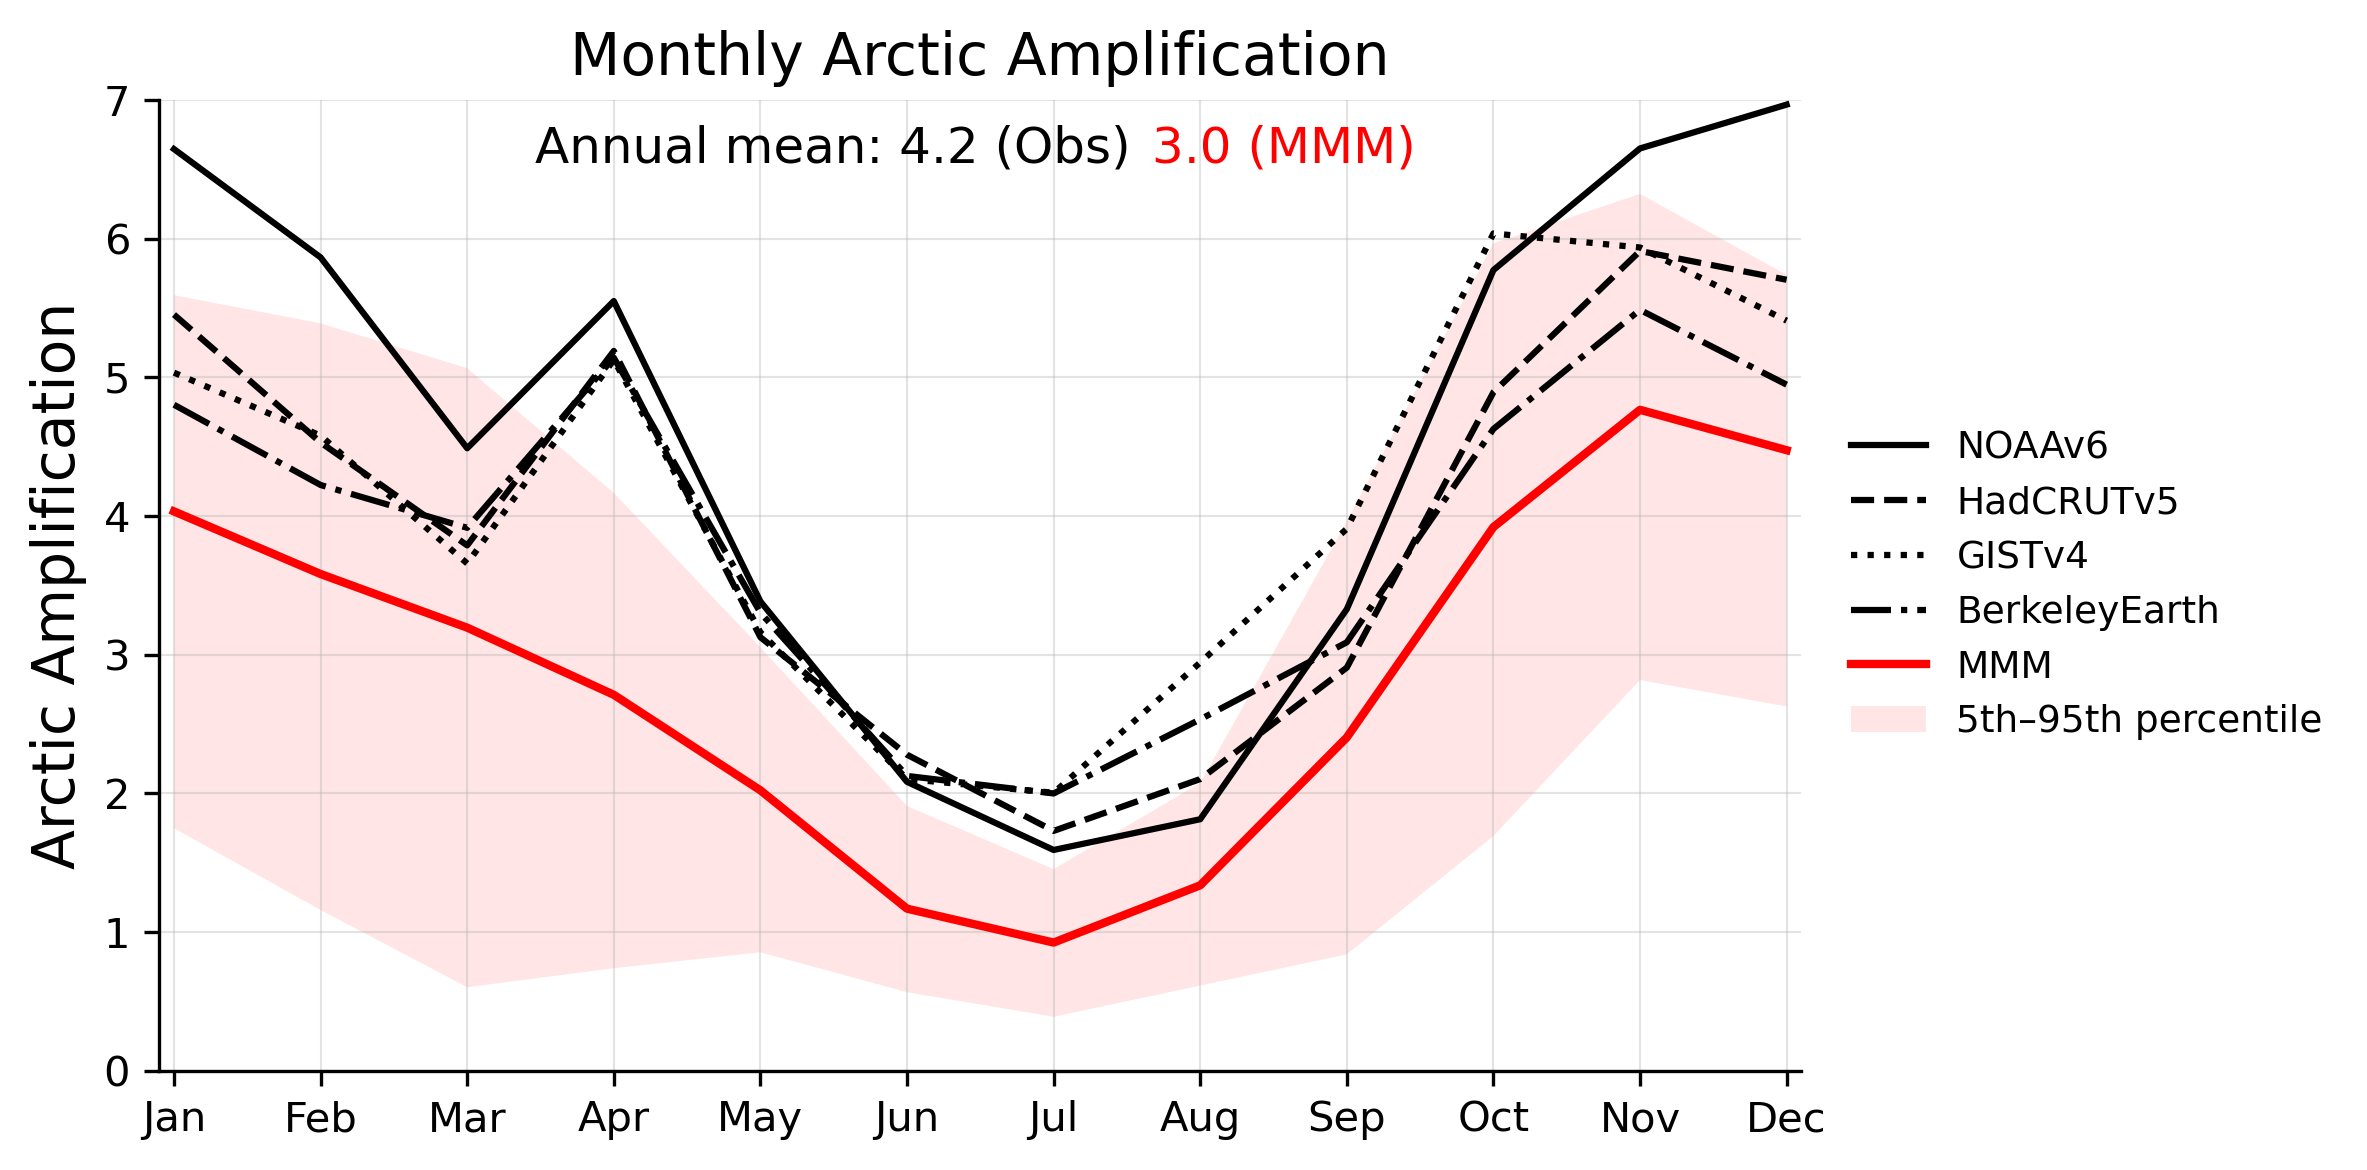

In [6]:
# ---- Per-dataset obs AA ----
obs_paths = load_obs_trends.__code__.co_varnames
_obs_arr = [xr.open_dataset(p).DATA for p in glob.glob('../data/obs-trends/SAT/*')]
lat_arr = _obs_arr[-1].lat.values
lon_arr = _obs_arr[-1].lon.values
arctic_idx = lat_arr >= 70
month_idx = list(range(12))

OBS_NAMES = ['NOAAv6', 'HadCRUTv5', 'GISTv4', 'BerkeleyEarth']
OBS_STYLES = [
    {'linestyle': '-',  'color': 'black', 'linewidth': 1.5},
    {'linestyle': '--', 'color': 'black', 'linewidth': 1.5},
    {'linestyle': ':',  'color': 'black', 'linewidth': 1.5},
    {'linestyle': '-.', 'color': 'black', 'linewidth': 1.5},
]

obs_aa_all = []
for ds in _obs_arr:
    data = ds.values if hasattr(ds, 'values') else np.array(ds)
    arc = np.array([spatial_average(data[m, arctic_idx], lat_arr[arctic_idx]) for m in month_idx])
    glb = np.array([spatial_average(data[m], lat_arr) for m in month_idx])
    obs_aa_all.append(arc / glb)
obs_aa_all = np.array(obs_aa_all)
obs_aa_spring = np.nanmean(obs_aa_all[:, 2:5])

# ---- Per-member AA for percentile shading ----
_sim_paths = glob.glob('../data/sim-trends/*')
_mod_arr = []
for path in _sim_paths:
    ds = xr.open_dataset(path).X_SAT_SLP.isel(period=-6)
    _mod_arr.append(ds[:, :, :, :, 0].values * (0.213 / 0.260))

all_member_aa = []
for mod in _mod_arr:
    for mem in range(mod.shape[0]):
        md_ = mod[mem]
        arc = np.array([spatial_average(md_[m, arctic_idx], lat_arr[arctic_idx]) for m in month_idx])
        glb = np.array([spatial_average(md_[m], lat_arr) for m in month_idx])
        all_member_aa.append(arc / glb)
all_member_aa = np.array(all_member_aa)
print(f"Total members: {all_member_aa.shape[0]}")

pct5 = np.percentile(all_member_aa, 5, axis=0)
pct95 = np.percentile(all_member_aa, 95, axis=0)

model_means_aa = []
for mod in _mod_arr:
    em = np.nanmean(mod, axis=0)
    arc = np.array([spatial_average(em[m, arctic_idx], lat_arr[arctic_idx]) for m in month_idx])
    glb = np.array([spatial_average(em[m], lat_arr) for m in month_idx])
    model_means_aa.append(arc / glb)
mmm_aa = np.nanmean(model_means_aa, axis=0)
mmm_aa_spring = np.nanmean(mmm_aa[2:5])

# ---- Plot ----
x = list(range(12))
fig, ax = plt.subplots(figsize=(8, 4), dpi=DPI)

for aa, name, style in zip(obs_aa_all, OBS_NAMES, OBS_STYLES):
    ax.plot(x, aa, label=name, **style)

ax.plot(x, mmm_aa, '-', color='red', linewidth=2, label='MMM')
ax.fill_between(x, pct5, pct95, alpha=0.1, color='red', label='5th–95th percentile', edgecolor='none')

ax.text(0.41, 0.975, f'Annual mean: {obs_aa_spring:.1f} (Obs)', transform=ax.transAxes, fontsize=FS_TICK, color='black', ha='center', va='top')
ax.text(0.685, 0.975, '3.0 (MMM)', transform=ax.transAxes, fontsize=FS_TICK, color='red', ha='center', va='top')

ax.set_title('Monthly Arctic Amplification', fontsize=FS_LABEL)
ax.set_ylabel('Arctic Amplification', fontsize=FS_LABEL)
ax.set_xticks(x)
ax.set_xticklabels(MONTHS_ALL, fontsize=10)
ax.set_xlim(-0.1, 11.1)
ax.set_ylim(0, 7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='-', alpha=0.35, linewidth=0.5)
ax.legend(frameon=False, fontsize=9, loc='center left', bbox_to_anchor=(1.01, 0.5))

plt.tight_layout()
plt.savefig('../figures/Figure1.png', dpi=DPI, bbox_inches='tight')
plt.show()

## Figure 2: Observed SAT and SLP trend maps
2 rows × 3 months. Row 1: SAT (filled). Row 2: SLP (filled). Stippling where trend is significant at 95% (OLS t-test with effective N from lag-1 autocorrelation).

In [3]:
# Pre-compute significance masks

print("Computing SAT significance masks...")
sig_sat = [significance_mask(obs_sat_ts_maps[:, col, :, :]) for col in range(3)]

print("Computing SLP significance masks...")
sig_slp = [significance_mask(obs_slp_ts_maps[:, col, :, :]) for col in range(3)]

print("Done.")

Computing SAT significance masks...
Computing SLP significance masks...
Done.


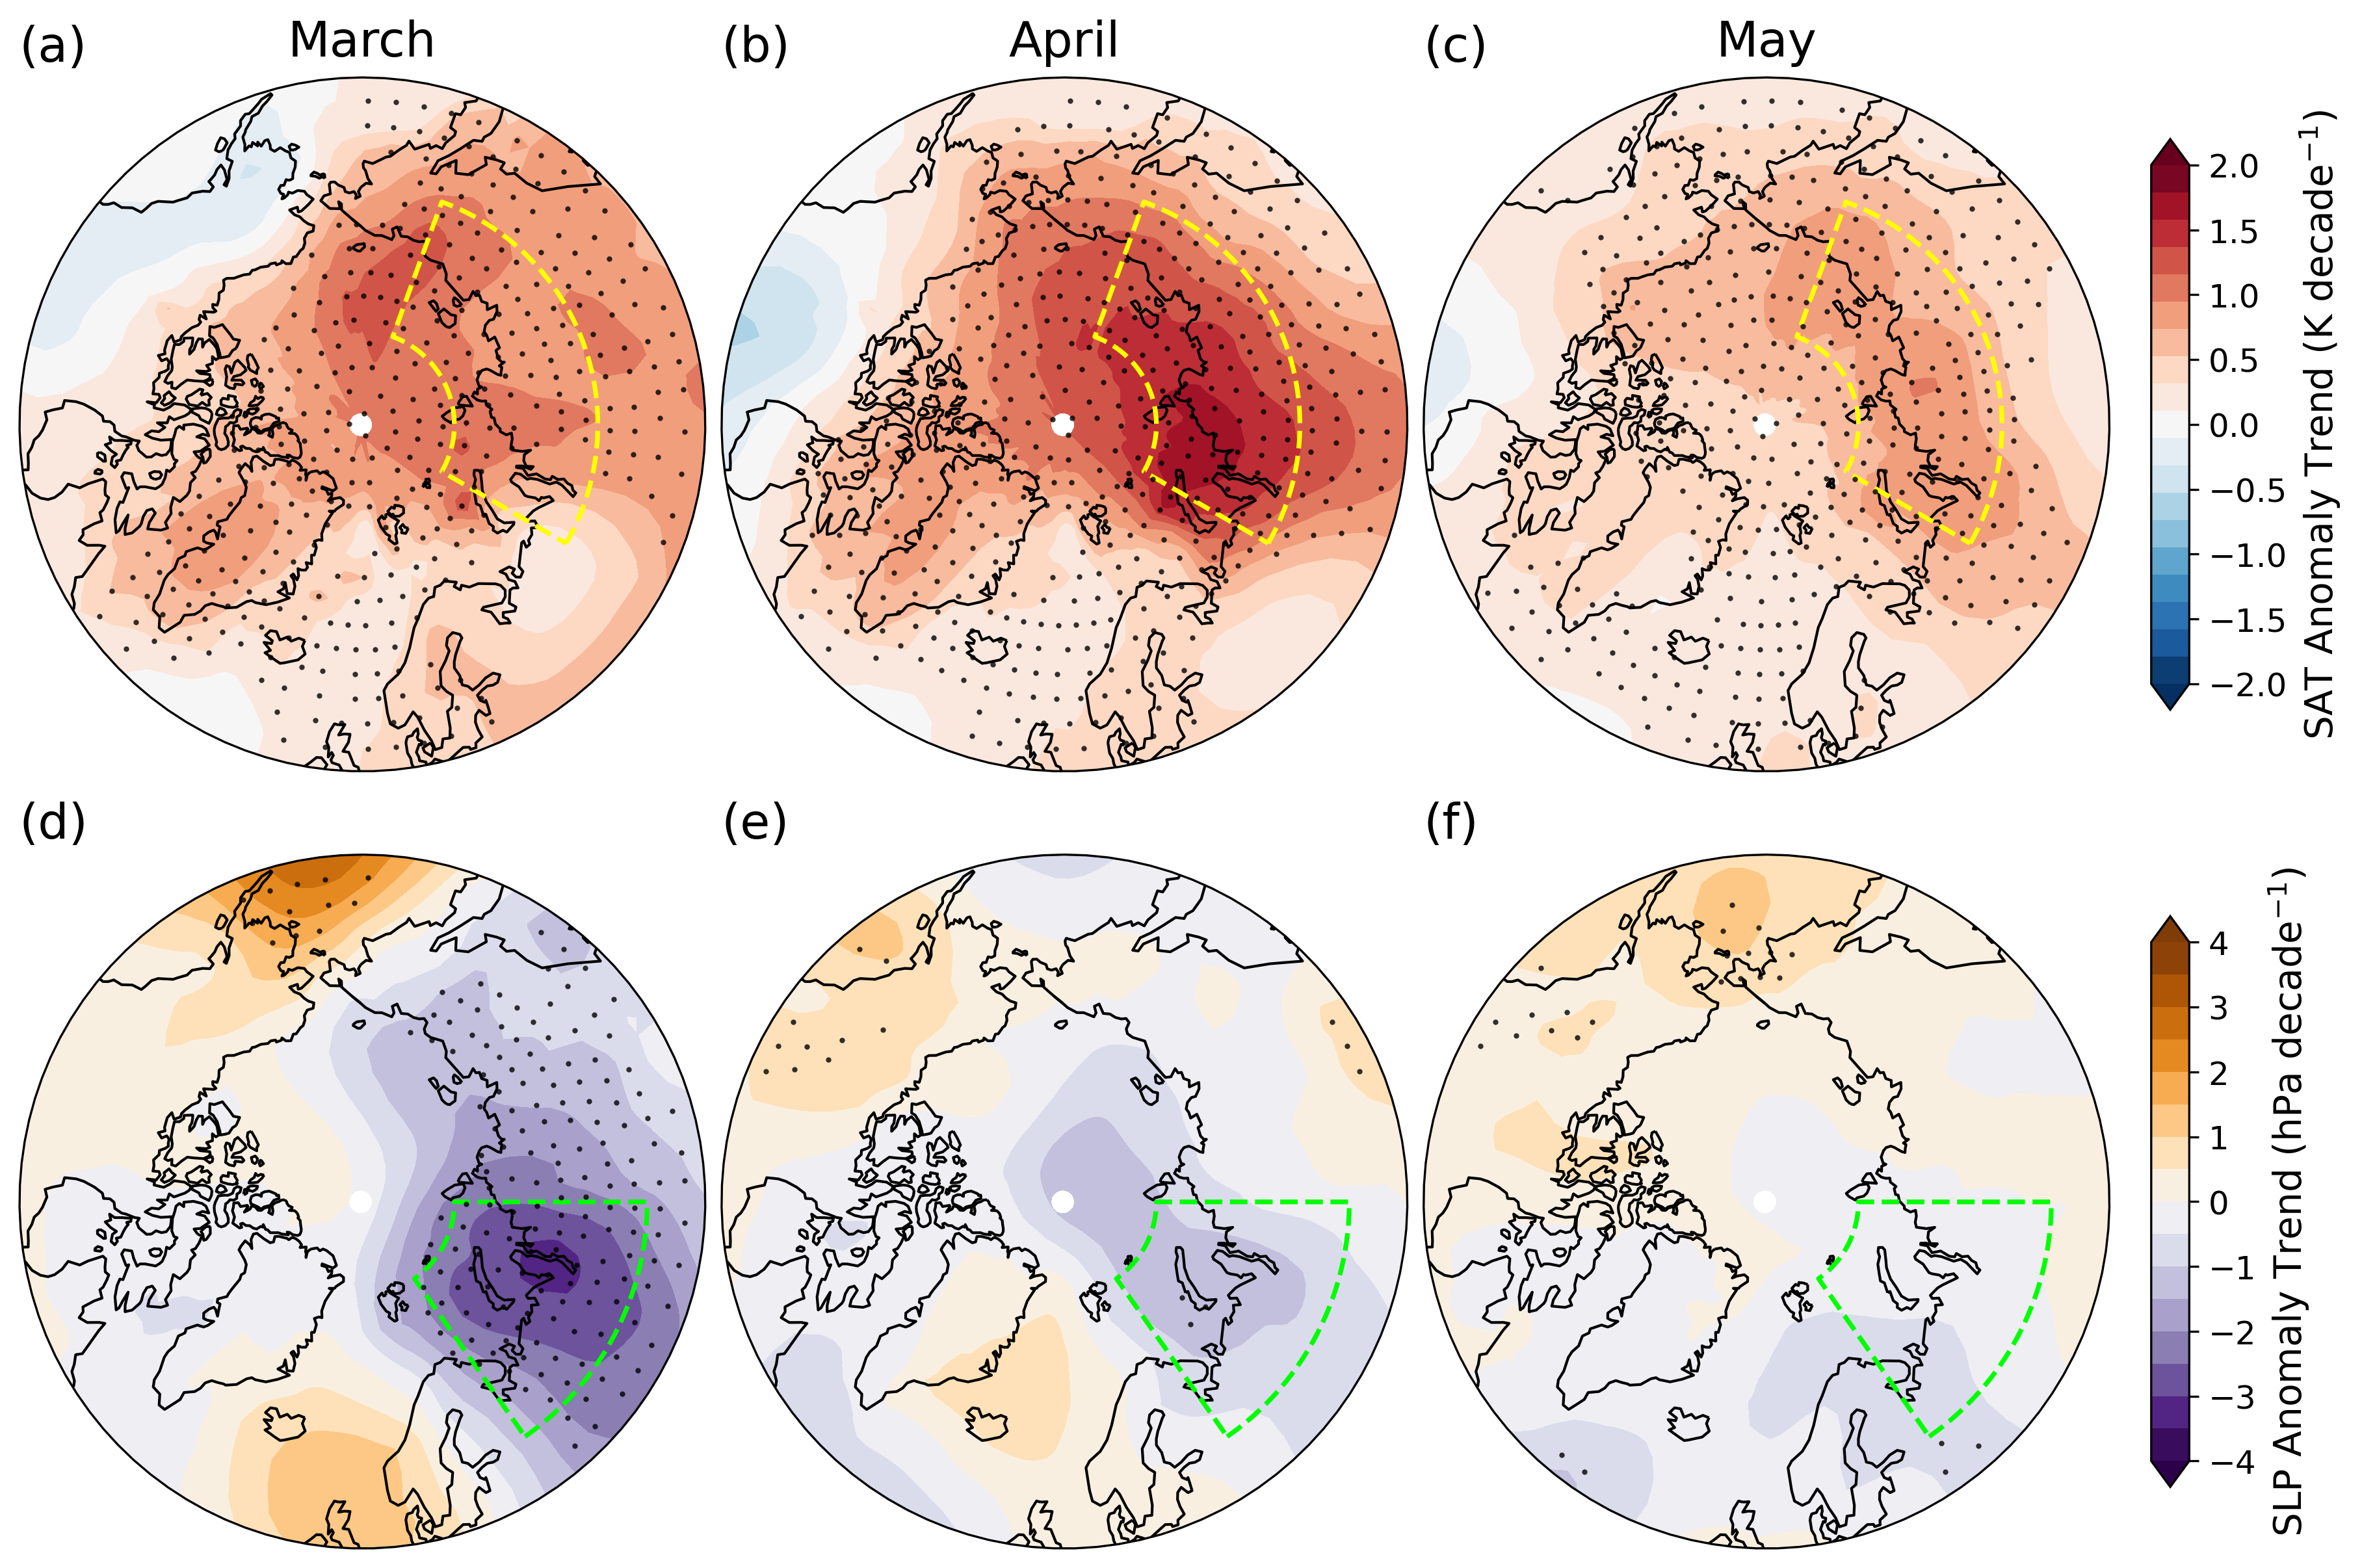

In [4]:
fig, axes = plt.subplots(
    2, 3, figsize=(12, 8), dpi=DPI,
    subplot_kw={'projection': ccrs.NorthPolarStereo()},
    constrained_layout=True
)

for col in range(3):
    for row in range(2):
        ax = axes[row, col]
        polar_ax(ax)
        label = f"({PANEL_LABELS[row * 3 + col]})"

        if row == 0:
            data_cyc, lon_cyc = add_cyclic_point(obs_sat[col], coord=lon)
            im_sat = ax.contourf(lon_cyc, lat, data_cyc, cmap='RdBu_r',
                                 levels=SAT_LEVELS, extend='both',
                                 transform=ccrs.PlateCarree())
            ax.set_title(f"{label}", fontsize=18, loc='left')
            ax.text(0.5, 1.05, MONTHS[col], transform=ax.transAxes, fontsize=18, va='center', ha='center')
            plot_region(ax, 60, 160, 65, 80, color='yellow', linewidth=1.75, linestyle='--')
            add_stippling(ax, sig_sat[col], lons_ts, lats_ts)
        else:
            data_cyc, lon_cyc = add_cyclic_point(obs_slp[col], coord=lon)
            im_slp = ax.contourf(lon_cyc, lat, data_cyc, cmap='PuOr_r',
                                 levels=SLP_LEVELS, extend='both',
                                 transform=ccrs.PlateCarree())
            ax.set_title(label, fontsize=18, loc='left')
            plot_region(ax, 35, 90, 60, 80, color='lime', linewidth=1.75, linestyle='--')
            add_stippling(ax, sig_slp[col], lons_ts, lats_ts)

add_colorbar(fig, im_sat, axes[0, :].ravel(), "SAT Anomaly Trend (K decade$^{-1}$)", np.linspace(-2, 2, 9))
add_colorbar(fig, im_slp, axes[1, :].ravel(), "SLP Anomaly Trend (hPa decade$^{-1}$)",  np.linspace(-4, 4, 9))

plt.savefig('../figures/Figure2.png', dpi=DPI, bbox_inches='tight')
plt.show()

---
## Figure 3 — SAT breakdown: MMM / Obs−MMM / PInudge

3 rows × 3 months. Stippling on all rows. Area-weighted pattern correlation on PInudge row.

In [3]:
# Pre-compute significance masks

print("Computing MMM significance masks...")
sig_mmm = [significance_mask(mod_sat_ts_maps[:, col, :, :]) for col in range(3)]

print("Computing Obs-MMM significance masks...")
diff_maps = obs_sat_ts_maps - mod_sat_ts_maps
sig_diff = [significance_mask(diff_maps[:, col, :, :]) for col in range(3)]

print("Computing PInudge significance masks...")
nudged_maps = np.nanmean(nudged_sat_ts, axis=0)
sig_nudged = [significance_mask(nudged_maps[:, col, :, :]) for col in range(3)]

print("Done.")

Computing MMM significance masks...
Computing Obs-MMM significance masks...
Computing PInudge significance masks...
Done.


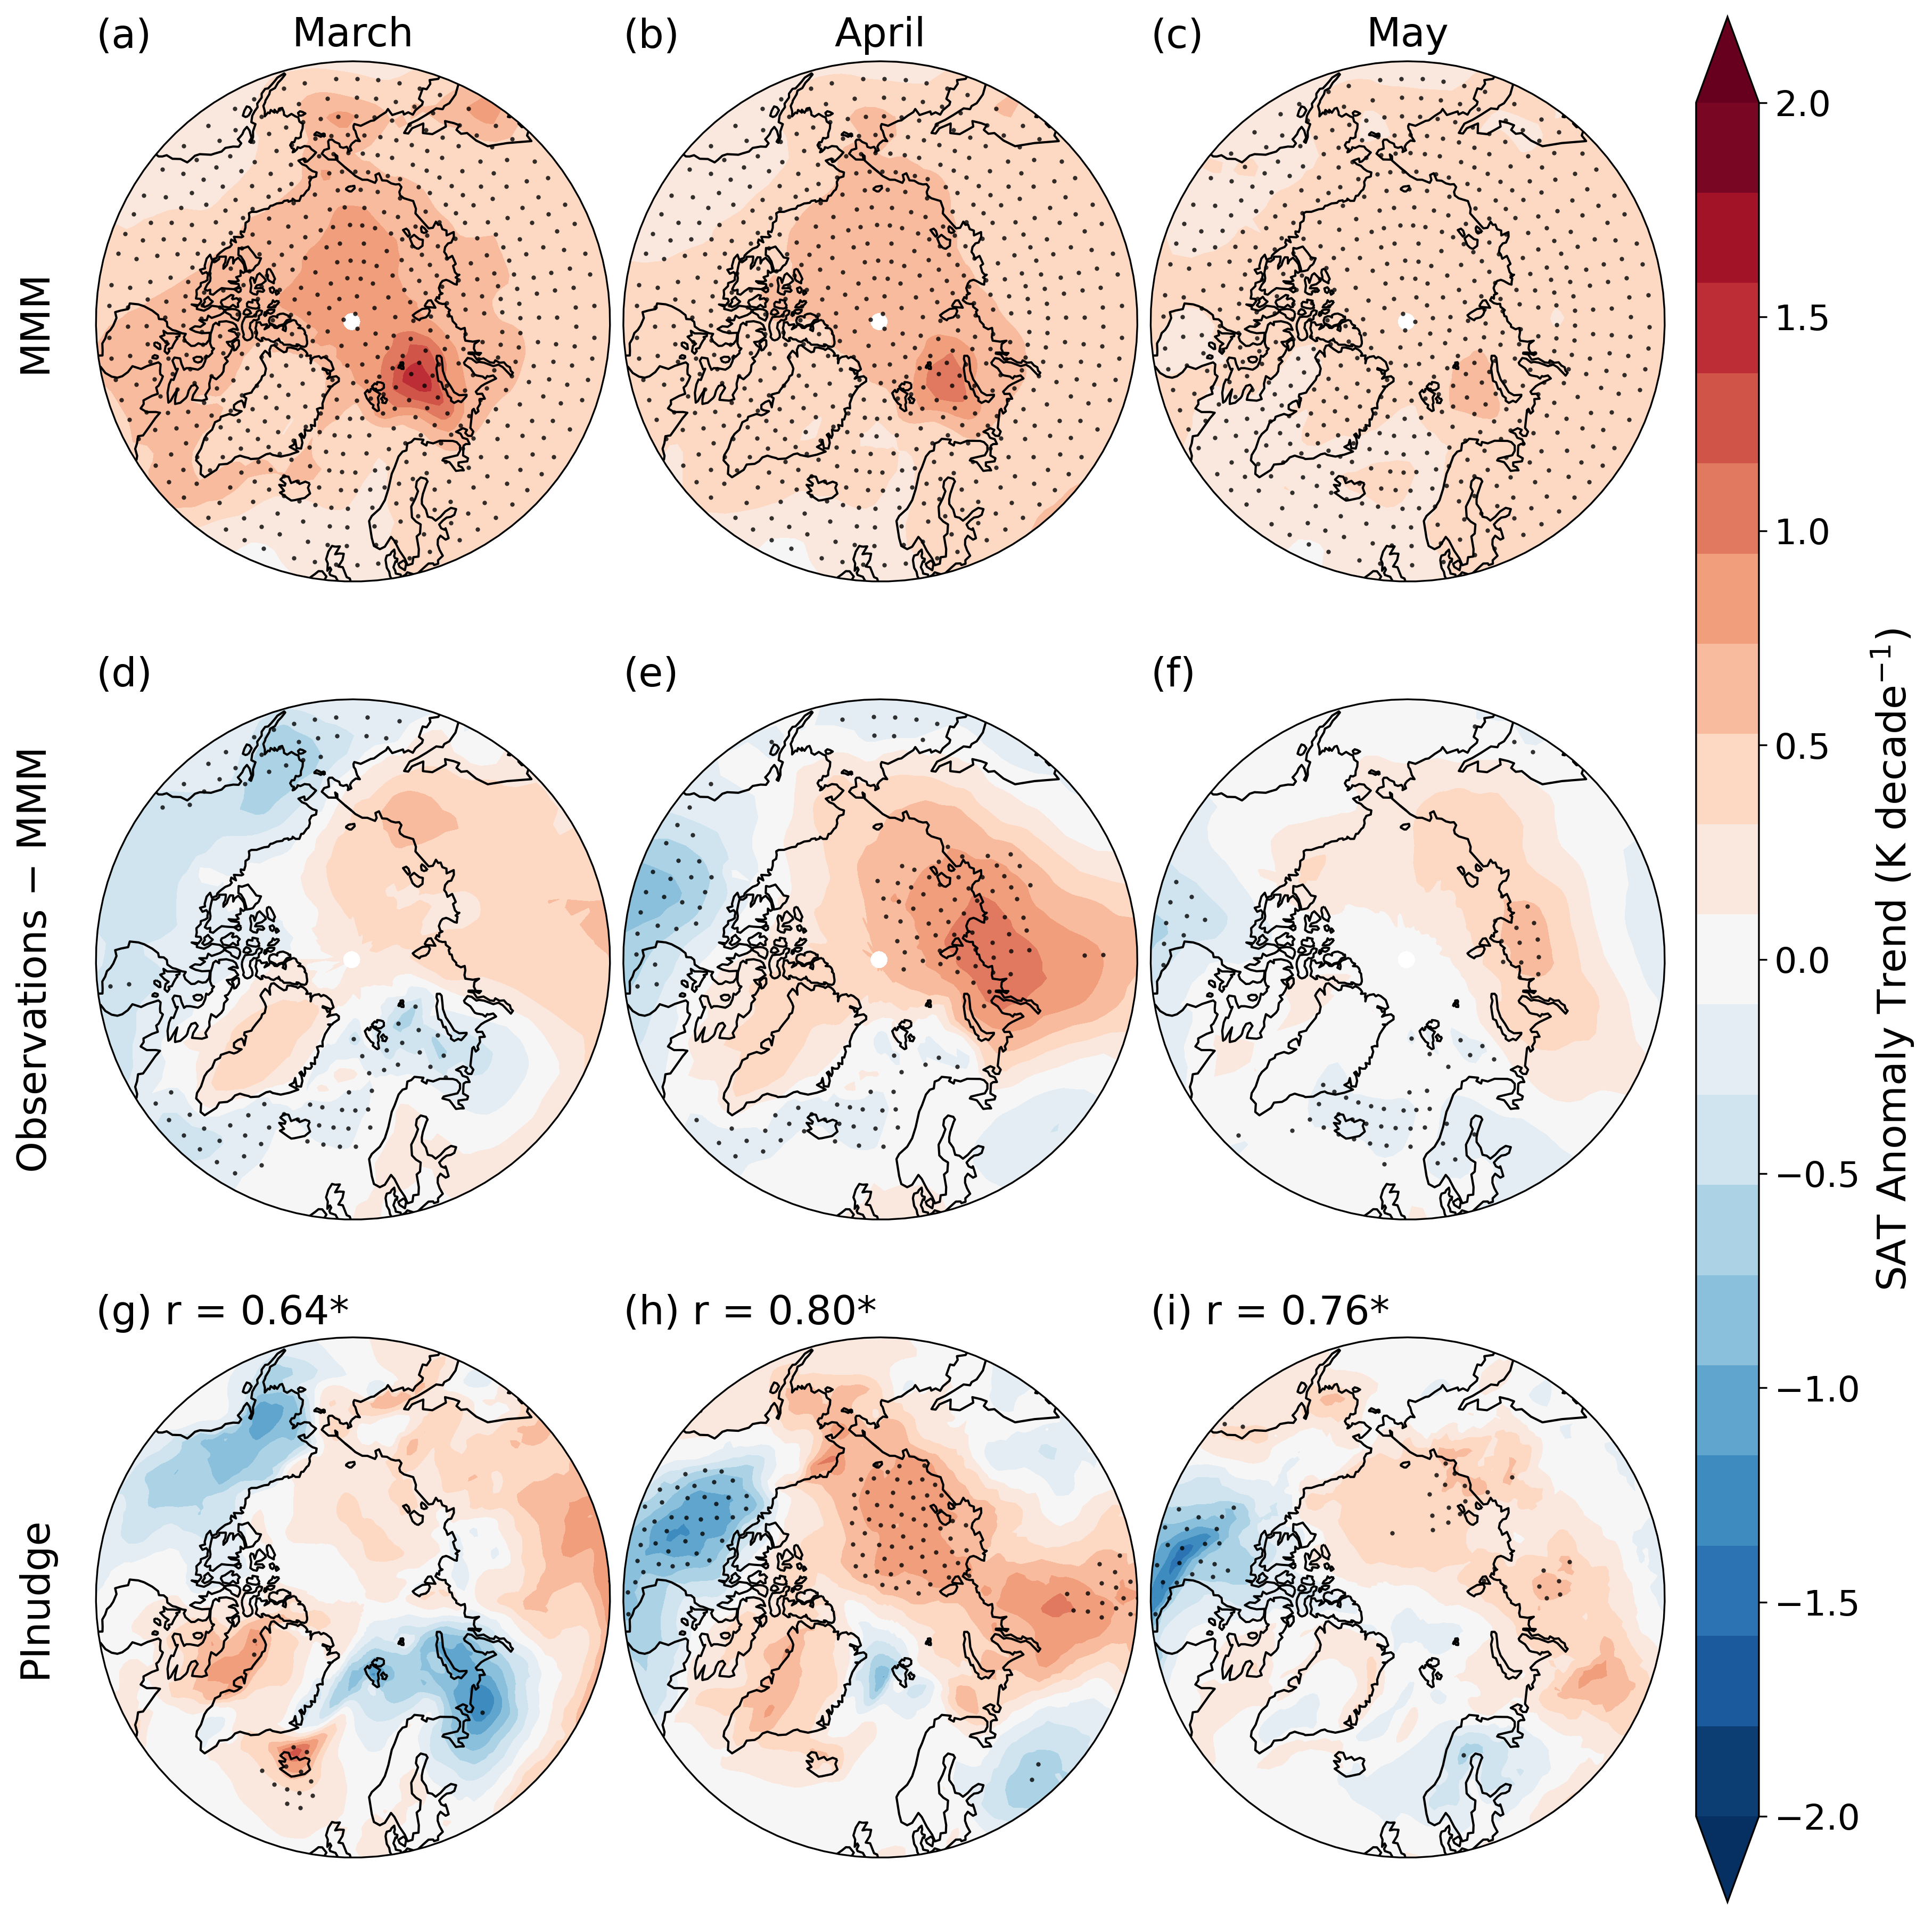

In [5]:
row_heads = ["MMM", "Observations − MMM", "PInudge"]

fig, axes = plt.subplots(
    3, 3, figsize=(12, 12), dpi=DPI,
    subplot_kw={'projection': ccrs.NorthPolarStereo()},
    constrained_layout=True
)

for col in range(3):
    for row in range(3):
        ax = axes[row, col]
        polar_ax(ax)
        label = f"({PANEL_LABELS[row * 3 + col]})"

        if row == 0:
            ax.text(0.5, 1.05, MONTHS[col], transform=ax.transAxes,
                    fontsize=18, va='center', ha='center')
        if col == 0:
            ax.text(-0.08, 0.5, row_heads[row], transform=ax.transAxes,
                    fontsize=18, va='center', ha='right', rotation=90)

        if row == 0:
            sat_map, lats, lons = mod_sat[col], lat, lon
            add_stippling(ax, sig_mmm[col], lons_ts, lats_ts)

        elif row == 1:
            diff = obs_sat[col] - mod_sat[col]
            sat_map, lats, lons = diff, lat, lon
            add_stippling(ax, sig_diff[col], lons_ts, lats_ts) 

        else:
            sat_map = nudged_sat[col]
            lats = nudged_trends.lat.values
            lons = nudged_trends.lon.values
            add_stippling(ax, sig_nudged[col], lons, lats)

        sat_cyc, lon_cyc = add_cyclic_point(sat_map, coord=lons)
        im = ax.contourf(lon_cyc, lats, sat_cyc, cmap='RdBu_r',
                         levels=SAT_LEVELS, extend='both',
                         transform=ccrs.PlateCarree())

        if row == 2:
            diff_rg = obs_sat[col] - mod_sat[col]
            lat_mask = lat >= 60
            r, p = weighted_corrcoef_pvalue(
                nudged_sat_rg[col][lat_mask],
                diff_rg[lat_mask],
                lat[lat_mask]
            )
            sig = '*' if p < 0.05 else ''
            ax.set_title(f"{label} r = {r:.2f}{sig}", fontsize=18, loc='left')
        else:
            ax.set_title(label, fontsize=18, loc='left')

cbar = fig.colorbar(
    im,
    ax=axes.ravel(),
    orientation='vertical',
    ticks=np.linspace(-2, 2, 9),
    shrink=0.995,
    aspect=30,
    pad=0.02
)
cbar.ax.tick_params(labelsize=16)
cbar.set_label("SAT Anomaly Trend (K decade$^{-1}$)", fontsize=18)

# plt.savefig('../figures/Figure3.png', dpi=DPI, bbox_inches='tight')
plt.show()

Computing Obs-PInudge significance masks...
Done.


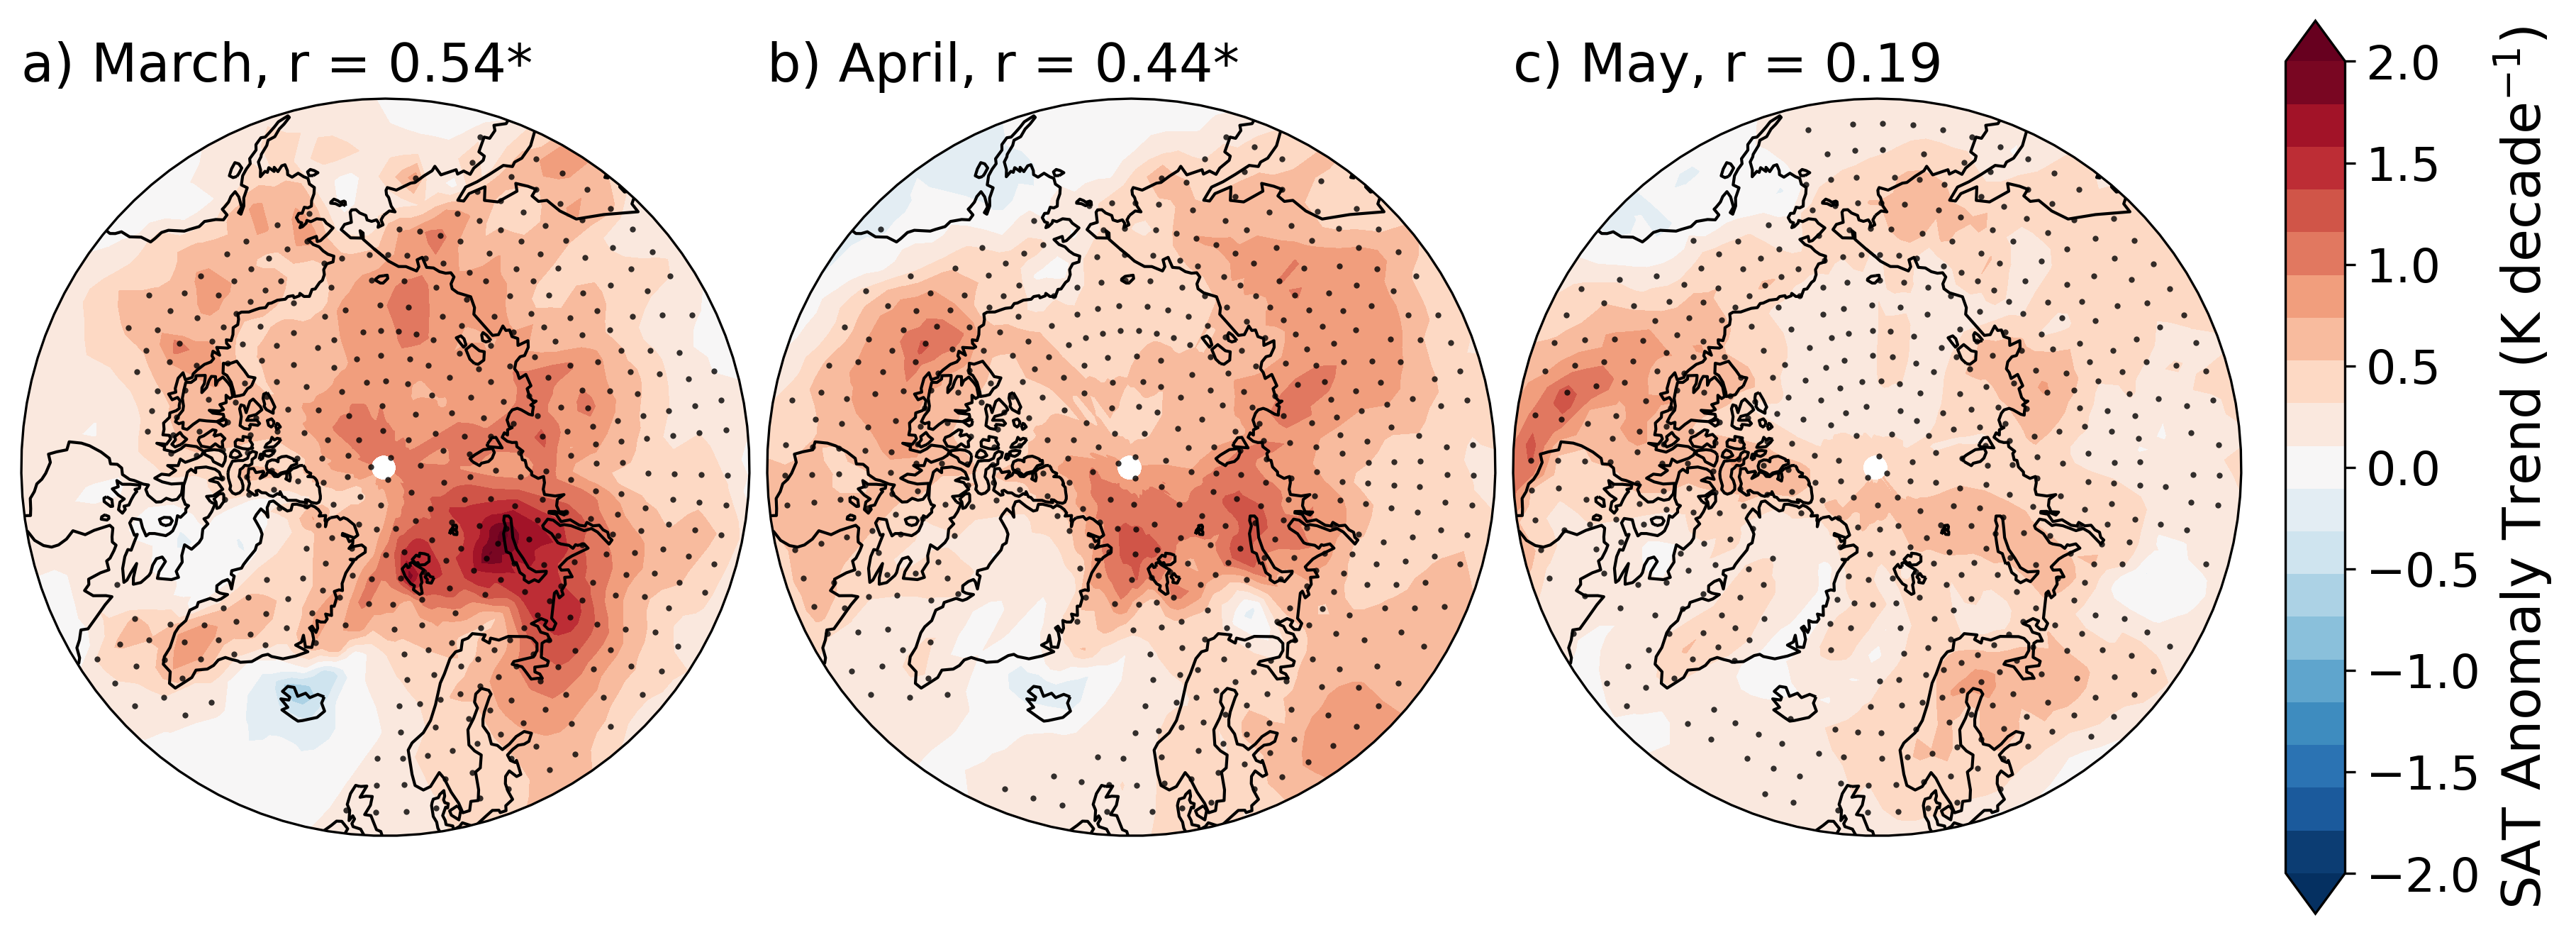

In [3]:
print("Computing Obs-PInudge significance masks...")
diff_maps2 = obs_sat_ts_maps - nudged_sat_ts_rg[:, :, 44:]
diff2_nudged = [significance_mask(diff_maps2[:, col, :, :]) for col in range(3)]

print("Done.")

fig, axes = plt.subplots(
    1, 3, figsize=(12, 4.5), dpi=DPI,
    subplot_kw={'projection': ccrs.NorthPolarStereo()},
    constrained_layout=True
)

for col in range(3):
    ax = axes[col]
    polar_ax(ax)
    label = f"{PANEL_LABELS[col]}) {MONTHS[col]},"

    diff = obs_sat[col] - nudged_sat_rg[col]
    sat_map, lats, lons = diff, lat, lon

    sat_cyc, lon_cyc = add_cyclic_point(sat_map, coord=lons)
    im = ax.contourf(lon_cyc, lats, sat_cyc, cmap='RdBu_r',
                     levels=SAT_LEVELS, extend='both',
                     transform=ccrs.PlateCarree())
    add_stippling(ax, diff2_nudged[col], lons, lats[44:])

    lat_mask = lat >= 60
    r, p = weighted_corrcoef_pvalue(
        diff[lat_mask],
        mod_sat[col][lat_mask],
        lat[lat_mask]
    )
    sig = '*' if p < 0.05 else ''
    ax.set_title(f"{label} r = {r:.2f}{sig}", fontsize=18, loc='left')

cbar = fig.colorbar(
    im,
    ax=axes.ravel(),
    orientation='vertical',
    ticks=np.linspace(-2, 2, 9),
    shrink=0.95,
    aspect=15,
    pad=0.02
)
cbar.ax.tick_params(labelsize=16)
cbar.set_label("SAT Anomaly Trend (K decade$^{-1}$)", fontsize=18)
plt.savefig('../figures/FigureS5.png', dpi=DPI, bbox_inches='tight')
plt.show()

---
## Figure 4 — Vertical SAT structure

4 rows (Obs, MMM, Obs-MMM, PInudge) × 3 months.

In [4]:
# ---- Load ERA5 vertical temperature ----
ds_era5 = xr.open_dataset('../data/ERA5_Vertical_Temp.nc').t
ds_era5_sel = ds_era5.sel(valid_time=slice('1980-01-01', '2022-12-31'))
clim = ds_era5_sel.groupby('valid_time.month').mean('valid_time')
ds_era5_anom = ds_era5_sel.groupby('valid_time.month') - clim

vert_months = {3: 'March', 4: 'April', 5: 'May'}
obs_vert_trend = {}
obs_vert_ts = {}

for mon_num, mon_name in vert_months.items():
    da = ds_era5_anom.sel(valid_time=ds_era5_anom.valid_time.dt.month == mon_num, latitude=ds_era5_anom.latitude >= 60)

    zonal = da.mean(dim='longitude').values
    obs_vert_ts[mon_name] = zonal
    n_t = zonal.shape[0]
    t_vec = np.linspace(1980, 2022, n_t)
    slopes = np.full(zonal.shape[1:], np.nan)

    for ii in range(zonal.shape[1]):
        for jj in range(zonal.shape[2]):
            y = zonal[:, ii, jj]
            if np.sum(np.isfinite(y)) >= 2:
                slopes[ii, jj] = np.polyfit(t_vec, y, 1)[0] * 10

    obs_vert_trend[mon_name] = slopes

obs_lats_vert = da.latitude.values
obs_plevs = da.pressure_level.values

# ---- MMM vertical temperature ----
ds_mmm_vert = xr.open_dataset('../data/scaled_MMM_Vertical_Temp.nc')
mmm_vert_trend = {m: ds_mmm_vert[f'{m.lower()}_trend'].values for m in MONTHS}
mmm_lats_vert = ds_mmm_vert['march_trend'].lat.values
mmm_plevs = ds_mmm_vert['march_trend'].plev.values / 100

# ---- PInudge vertical temperature trend ----
# nudged_t shape: (3, lev, lat) — ensemble-mean zonal-mean T trend
nudged_lev = nudged_t.lev.values
nudged_lats_vert = nudged_t.lat.values

# ---- Interpolate everything onto the obs (ERA5) grid for differences ----
# Target grid: obs_lats_vert (lat ascending), obs_plevs (plev)
# All interp outputs will be (plev, lat) — matching obs_vert_trend

# Build query points on obs grid
lg_obs, pg_obs = np.meshgrid(obs_lats_vert, obs_plevs, indexing='ij')  # (lat, plev)
pts_obs = np.stack([lg_obs.ravel(), pg_obs.ravel()], axis=-1)

obs_minus_mmm = {}
nudged_vert_trend = {}
nudged_vert_interp = {}
obs_minus_nudged = {}

for i, m in enumerate(MONTHS):
    # Obs minus MMM: interpolate MMM onto the obs (lat, plev) grid then subtract
    interp_mmm = RegularGridInterpolator(
        (mmm_lats_vert, mmm_plevs), mmm_vert_trend[m].T,
        method='linear', bounds_error=False, fill_value=np.nan
    )
    mmm_interp = interp_mmm(pts_obs).reshape(lg_obs.shape).T  # (plev, lat)
    obs_minus_mmm[m] = obs_vert_trend[m] - mmm_interp

    # Obs minus PInudge: interpolate nudged onto the obs (lat, plev) grid then subtract
    nudged_vert_trend[m] = nudged_t[i]
    interp_nudge = RegularGridInterpolator(
        (nudged_lats_vert, nudged_lev), nudged_t[i].values.T,
        method='linear', bounds_error=False, fill_value=np.nan
    )
    nudged_vert_interp[m] = interp_nudge(pts_obs).reshape(lg_obs.shape).T  # (plev, lat)
    obs_minus_nudged[m] = obs_vert_trend[m] - nudged_vert_interp[m]

print(f"obs_vert_trend['March']:     {obs_vert_trend['March'].shape}")
print(f"mmm_vert_trend['March']:     {mmm_vert_trend['March'].shape}")
print(f"obs_minus_mmm['March']:      {obs_minus_mmm['March'].shape}")
print(f"nudged_vert_interp['March']: {nudged_vert_interp['March'].shape}")

print("\nSupplementary:")
print(f"obs_minus_nudged['March']:   {obs_minus_nudged['March'].shape}")

print("\nVertical data loaded.")

obs_vert_trend['March']:     (37, 121)
mmm_vert_trend['March']:     (19, 37)
obs_minus_mmm['March']:      (37, 121)
nudged_vert_interp['March']: (37, 121)

Supplementary:
obs_minus_nudged['March']:   (37, 121)

Vertical data loaded.


In [6]:
# Pre-compute significance masks

print("Computing Observations vertical significance masks...")
sig_vert_obs = {m: significance_mask(obs_vert_ts[m]) for m in MONTHS}

print("Computing MMM vertical significance masks...")
mmm_vert_ts = xr.open_dataset('../data/MMM_Vertical_Temp_timeseries.nc')
sig_vert_mmm = {
    m: significance_mask(mmm_vert_ts['ta'].isel(time=slice(i, None, 3)))
    for i, m in enumerate(MONTHS)
}

print("Computing Observations-MMM vertical significance masks...")
sig_vert_diff = {}
for i, m in enumerate(MONTHS):
    obs_da = obs_vert_ts[m]
    mmm_da = mmm_vert_ts['ta'].isel(time=slice(i, None, 3))

    # Regrid MMM (coarser) onto obs (finer) grid
    mmm_da_regridded = mmm_da.interp(plev=obs_plevs, lat=obs_lats_vert)

    diff_da = obs_da - mmm_da_regridded.values
    sig_vert_diff[m] = significance_mask(diff_da)

print("Computing PInudge vertical significance masks...")
nudged_t_ts_arr = np.asarray(nudged_t_ts)
sig_vert_nudged = {m: significance_mask(nudged_t_ts_arr[:, i, :, :]) for i, m in enumerate(MONTHS)}

print("Done.")

Computing Observations vertical significance masks...
Computing MMM vertical significance masks...
Computing Observations-MMM vertical significance masks...
Computing PInudge vertical significance masks...
Done.


In [ ]:
# ---- Plot ----
row_heads_vert = ["Observations", "MMM", "Obs − MMM", "PInudge"]
row_data = [
    {m: (obs_vert_trend[m], obs_lats_vert, obs_plevs) for m in MONTHS},
    {m: (mmm_vert_trend[m], mmm_lats_vert, mmm_plevs) for m in MONTHS},
    {m: (obs_minus_mmm[m], obs_lats_vert, obs_plevs) for m in MONTHS},
    {m: (nudged_vert_trend[m], nudged_lats_vert, nudged_lev) for m in MONTHS},
]

fig, axes = plt.subplots(4, 3, figsize=(12, 16), dpi=DPI, constrained_layout=True)
cf = None
for col, mon in enumerate(MONTHS):
    for row in range(4):
        ax = axes[row, col]
        data, lats_p, plevs_p = row_data[row][mon]
        cf = ax.contourf(lats_p, plevs_p, data, levels=np.linspace(-2, 2, 20), cmap='RdBu_r', extend='both')

        # Stippling where trend is significant (95%, autocorrelation-adjusted)
        if row == 0:
            add_stippling_cartesian(ax, sig_vert_obs[mon], lats_p, plevs_p)
        elif row == 1:
            add_stippling_cartesian(ax, sig_vert_mmm[mon], lats_p, plevs_p)
        elif row == 2:
            add_stippling_cartesian(ax, sig_vert_diff[mon], lats_p, plevs_p)
        elif row == 3:
            add_stippling_cartesian(ax, sig_vert_nudged[mon], lats_p, plevs_p)

        ax.invert_yaxis()
        ax.set_xlim(60, 90)
        ax.set_xticks([60, 70, 80, 90])
        ax.set_ylim(1000, 10)
        ax.set_yticks([1000, 700, 500, 300, 100, 10])
        ax.tick_params(labelsize=14)

        label = f"({PANEL_LABELS[row * 3 + col]})"
        ax.set_title(f"{label} {mon}" if row == 0 else label,
                     fontsize=18, loc='left')
        if col == 0:
            ax.set_ylabel('Pressure (hPa)', fontsize=16)
            ax.text(-0.355, 0.5, row_heads_vert[row], transform=ax.transAxes,
                    fontsize=18, va='center', ha='right', rotation=90)
        else:
            ax.set_yticklabels([])
        if row == 3:
            ax.set_xlabel('Latitude', fontsize=16)
        else:
            ax.set_xticklabels([])

cbar = fig.colorbar(
    cf,
    ax=axes.ravel(),
    orientation='vertical',
    ticks=np.linspace(-2, 2, 9),
    shrink=0.995,
    aspect=35,
    pad=0.02
)
cbar.ax.tick_params(labelsize=16)
cbar.set_label("Temperature Trend (K decade$^{-1}$)", fontsize=18)

# plt.savefig('../figures/Figure4.png', dpi=DPI, bbox_inches='tight')
plt.show()

In [ ]:
# Pre-compute significance masks

print("Computing Observations-PInudge vertical significance masks...")

sig_vert_diff2 = {m: significance_mask(nudged_t_ts_arr[:, i, :, :]) for i, m in enumerate(MONTHS)}

print("Done.")

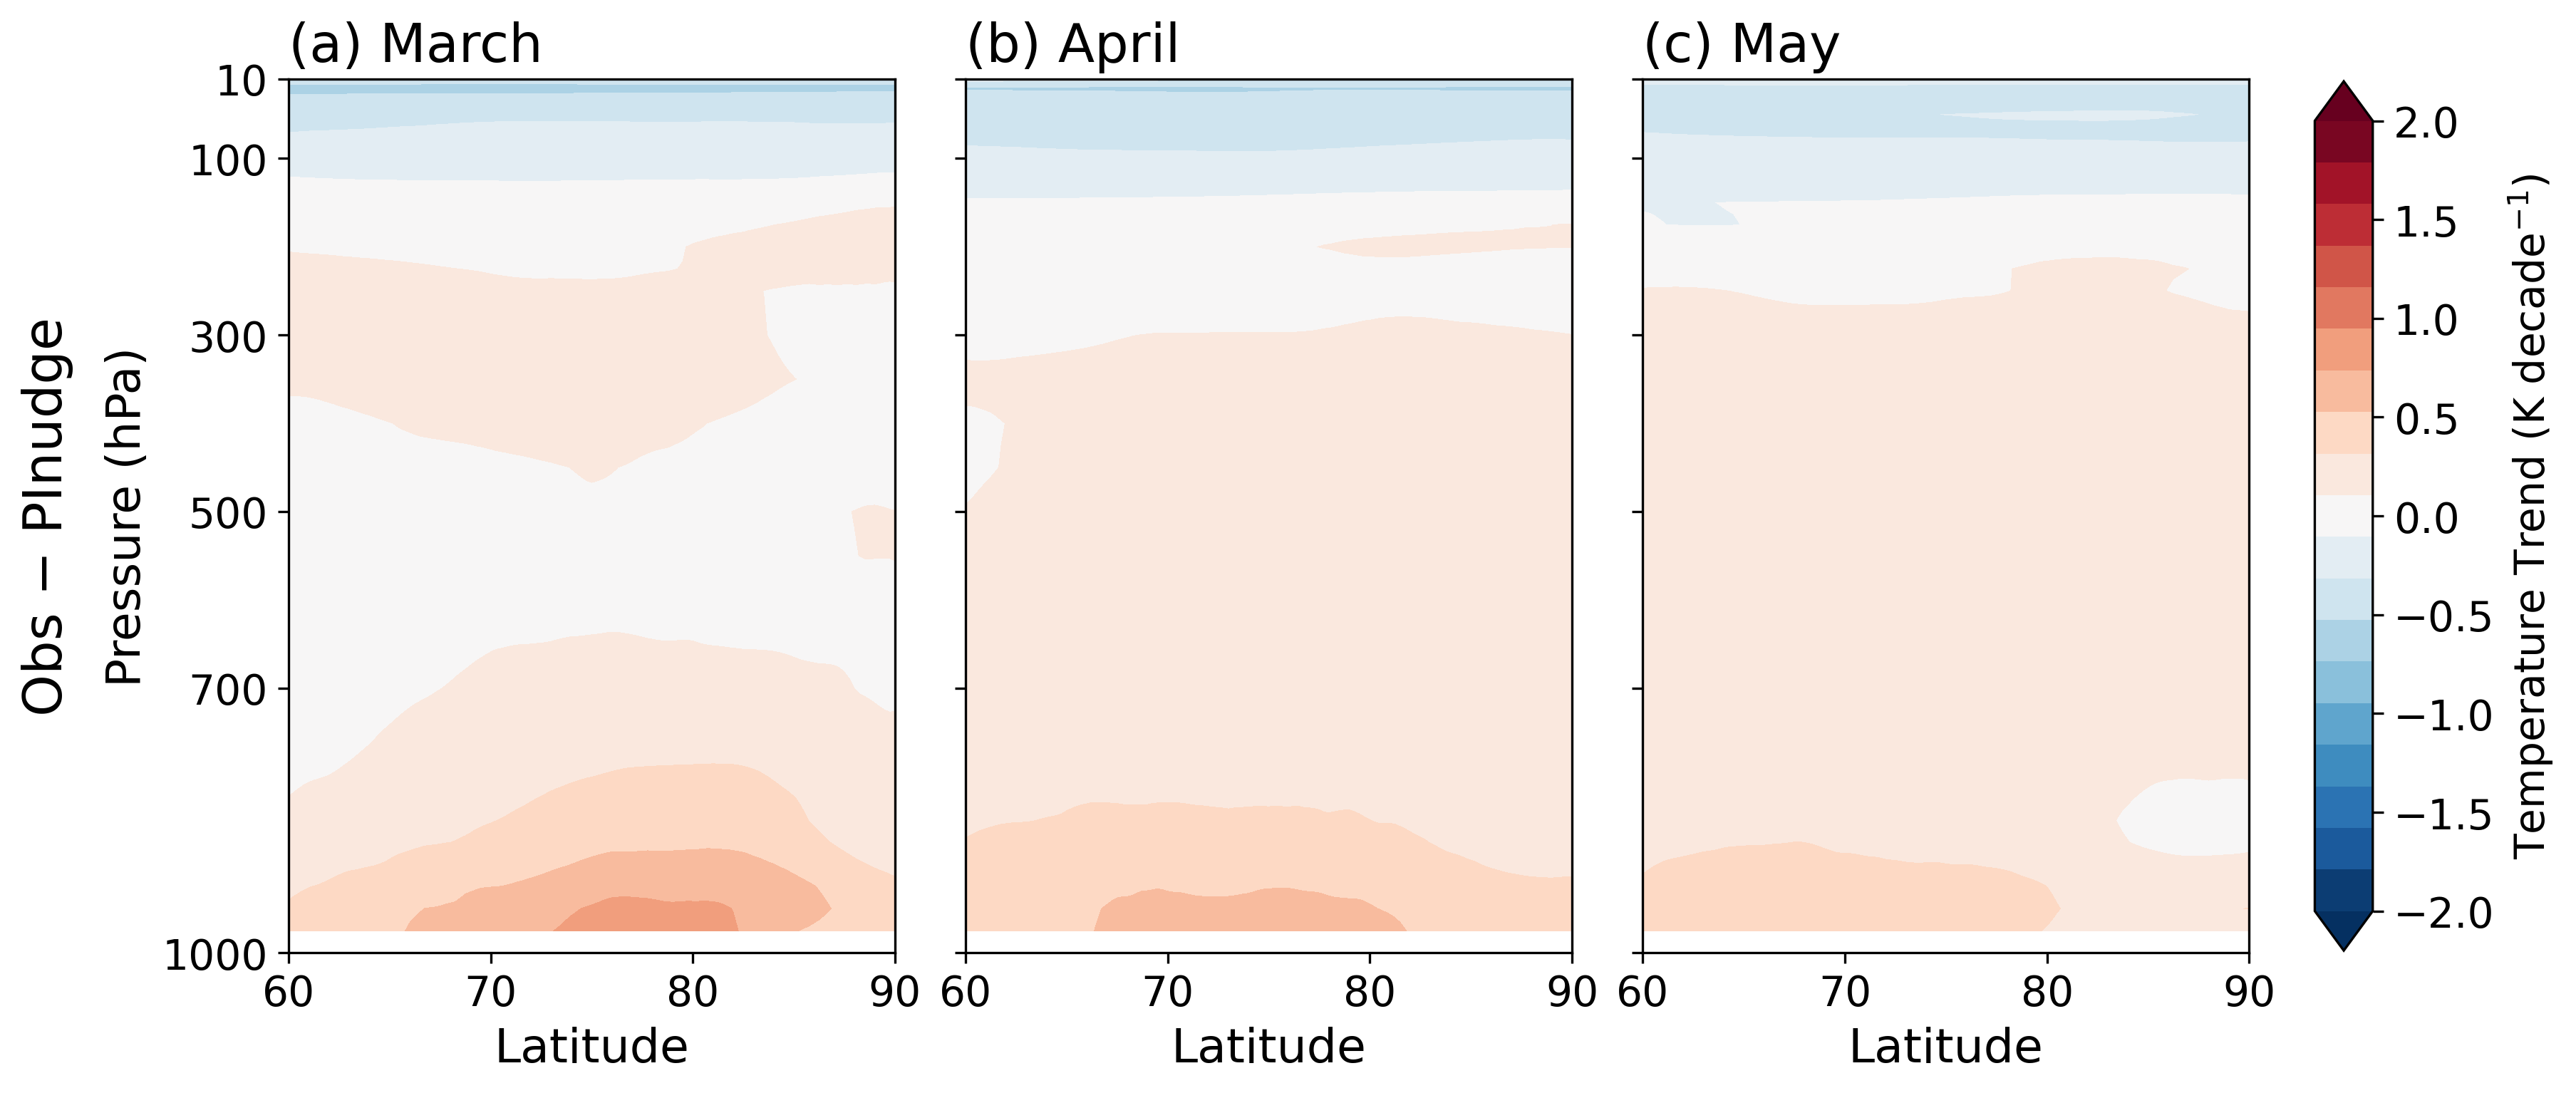

In [20]:
# ---- Plot ----
# All data is (plev, lat) — contourf(lats, plevs, data) needs (plev, lat) as-is
row_head_vert = "Obs − PInudge"
row_data = {m: (obs_minus_nudged[m], obs_lats_vert, obs_plevs) for m in MONTHS}

fig, axes = plt.subplots(1, 3, figsize=(12, 5), dpi=300, constrained_layout=True)
cf = None
for col, mon in enumerate(MONTHS):
    ax = axes[col]
    data, lats_p, plevs_p = row_data[mon]
    # contourf(x=lats, y=plevs, z) needs z shape (len(plevs), len(lats))
    # data is already (plev, lat) — correct
    cf = ax.contourf(lats_p, plevs_p, data, levels=np.linspace(-2, 2, 20), cmap='RdBu_r', extend='both')

    ax.invert_yaxis()
    ax.set_xlim(60, 90)
    ax.set_xticks([60, 70, 80, 90])
    ax.set_ylim(1000, 10)
    ax.set_yticks([1000, 700, 500, 300, 100, 10])
    ax.tick_params(labelsize=14)
    label = f"({PANEL_LABELS[col]})"
    ax.set_title(f"{label} {mon}", fontsize=18, loc='left')
    if col == 0:
        ax.set_ylabel('Pressure (hPa)', fontsize=16)
        ax.text(-0.355, 0.5, row_head_vert, transform=ax.transAxes,
                fontsize=18, va='center', ha='right', rotation=90)
    else:
        ax.set_yticklabels([])
    ax.set_xlabel('Latitude', fontsize=16)

cbar = fig.colorbar(
    cf,
    ax=axes.ravel(),
    orientation='vertical',
    ticks=np.linspace(-2, 2, 9),
    shrink=0.995,
    aspect=15,
    pad=0.02
)
cbar.ax.tick_params(labelsize=14)
cbar.set_label("Temperature Trend (K decade$^{-1}$)", fontsize=14)
# plt.savefig('../figures/FigureS6.png', dpi=DPI, bbox_inches='tight')
plt.show()

---
## Figure 5 — Zonal-mean U trend: ERA5 and MMM

In [1]:
ds_era5_u = xr.open_dataset('../data/ERA5_Vertical_U.nc').u
ds_era5_u = ds_era5_u.sel(valid_time=slice('1980-01-01', '2022-12-31'))
clim_u = ds_era5_u.groupby('valid_time.month').mean('valid_time')
ds_u_anom = ds_era5_u.groupby('valid_time.month') - clim_u

obs_u_trend = {}
obs_u_ts = {}   # full (time, plev, lat) series, kept for significance testing
for mon_num, mon_name in vert_months.items():
    da_u = ds_u_anom.sel(valid_time=ds_u_anom.valid_time.dt.month == mon_num)
    zonal = da_u.mean(dim='longitude').values
    obs_u_ts[mon_name] = zonal
    n_t = zonal.shape[0]
    t_vec = np.linspace(1980, 2022, n_t)
    slopes = np.full(zonal.shape[1:], np.nan)
    for i in range(zonal.shape[1]):
        for j in range(zonal.shape[2]):
            y = zonal[:, i, j]
            if np.sum(np.isfinite(y)) >= 2:
                slopes[i, j] = np.polyfit(t_vec, y, 1)[0] * 10
    obs_u_trend[mon_name] = slopes
obs_lats_u = da_u.latitude.values
obs_plevs_u = da_u.pressure_level.values

ds_mmm_u = xr.open_dataset('../data/MMM_Vertical_U.nc')
mmm_u_trend = {m: ds_mmm_u[f'{m.lower()}_trend'].values for m in MONTHS}
mmm_lats_u = ds_mmm_u['march_trend'].lat.values
mmm_plevs_u = ds_mmm_u['march_trend'].plev.values / 100
print("U data loaded.")

NameError: name 'xr' is not defined

In [ ]:
# Pre-compute significance masks
print("Computing zonal-mean U significance masks (Observations)...")
insig_u_obs = {m: significance_mask(obs_u_ts[m]) for m in MONTHS}

print("Computing zonal-mean U significance masks (MMM)...")
ds_mmm_u_ts = xr.open_dataset('../data/MMM_Vertical_U_timeseries.nc').ua
insig_u_mmm = {m: significance_mask(ds_mmm_u_ts.sel(time=ds_mmm_u_ts.month == m).values) for m in MONTHS}

print("Done.")

In [ ]:
row_heads_u = ["Observations", "MMM"]
fig, axes = plt.subplots(2, 3, figsize=(12, 10), dpi=DPI, sharex='col', sharey='row', constrained_layout=True)
for col, mon in enumerate(MONTHS):
    for row in range(2):
        ax = axes[row, col]
        if row == 0:
            data, lats_u, plevs_u = obs_u_trend[mon], obs_lats_u, obs_plevs_u
        else:
            data, lats_u, plevs_u = mmm_u_trend[mon], mmm_lats_u, mmm_plevs_u

        cf_u = ax.contourf(lats_u, plevs_u, data, levels=np.linspace(-1, 1, 20), cmap='RdBu_r', extend='both')

        # Stippling where trend is not significant (95%, autocorrelation)
        if row == 0:
            add_stippling_cartesian(ax, insig_u_obs[mon], lats_u, plevs_u)
        if row == 1:
            add_stippling_cartesian(ax, insig_u_mmm[mon], lats_u, plevs_u)

        ax.invert_yaxis()
        ax.set_xlim(60, 90)
        ax.set_xticks([60, 70, 80, 90])
        ax.set_ylim(1000, 10)
        ax.set_yticks([1000, 700, 500, 300, 100, 10])
        ax.tick_params(labelsize=14)

        label = f"({PANEL_LABELS[row * 3 + col]})"
        ax.set_title(f"{label} {mon}" if row == 0 else label, fontsize=18, loc='left')
        if col == 0:
            ax.set_ylabel('Pressure (hPa)', fontsize=16)
            ax.text(-0.35, 0.5, row_heads_u[row], transform=ax.transAxes,
                    fontsize=18, va='center', ha='right', rotation=90)
        if row == 1:
            ax.set_xlabel('Latitude', fontsize=16)

cbar = fig.colorbar(
    cf_u,
    ax=axes.ravel(),
    orientation='vertical',
    ticks=np.linspace(-1, 1, 9),
    shrink=0.995,
    aspect=25,
    pad=0.02
)
cbar.ax.tick_params(labelsize=16)
cbar.set_label("Easterly Wind Trend (m s$^{-1}$ decade$^{-1}$)", fontsize=18)

# plt.savefig('../figures/Figure5.png', dpi=DPI, bbox_inches='tight')
plt.show()

---
## Figure 6 — Density scatter: internal SLP–SAT distribution

Mahalanobis D² p-values added.

In [ ]:
xi = np.linspace(-3.5, 3.5, 150)
yi = np.linspace(-1.5, 1.5, 150)
Xg, Yg = np.meshgrid(xi, yi)
Z_all, x_avgs, y_avgs = [], [], []

for m in range(3):
    x = slp_internal[:, m, 60:68, 14:35] / 100
    y = sat_internal[:, m, 62:68, 24:63]
    x_avg = spatial_average(x, lat[60:68], len(lon[14:35]))
    y_avg = spatial_average(y, lat[62:68], len(lon[24:63]))
    x_avgs.append(x_avg)
    y_avgs.append(y_avg)
    kde = gaussian_kde(np.vstack([x_avg, y_avg]))
    Z = kde(np.vstack([Xg.ravel(), Yg.ravel()])).reshape(Xg.shape)
    Z_all.append(Z / Z.max())

OBSERVED = [
    (-2.368718114595667,   0.32643064679727984),   # March
    (-0.7940412441449607,  0.8526703529858402),    # April
    (-0.29191823970081302, 0.4206435706147982),    # May
]

NUDGED = [
    (-1.7854258732416266, 0.016964273004145818),   # March
    (-0.7681126518543514, 0.5215546178562999),    # April
    (-0.18799142781732106, 0.2571610729105704),    # May
]

density_levels = [0.1, 0.25, 0.5, 0.75, 0.9]
fig, axes = plt.subplots(1, 3, figsize=(12, 4), dpi=DPI, constrained_layout=True, sharey=True)

for m in range(3):
    ax = axes[m]
    x_avg, y_avg = x_avgs[m], y_avgs[m]
    obs_x, obs_y = NUDGED[m]
    r, p_r = stats.pearsonr(x_avg, y_avg)
    D2, p_mah = mahalanobis_pvalue(x_avg, y_avg, obs_x, obs_y)

    ax.scatter(x_avg, y_avg, color='lightgrey', alpha=0.3, s=5, edgecolors='none')
    ax.contour(Xg, Yg, Z_all[m], levels=density_levels, colors='red', linewidths=1.2)
    ax.scatter(obs_x, obs_y, color='blue', marker='*', s=90, zorder=5, label='PInudge')  # Observed
    ax.axhline(0, color='k', lw=0.8)
    ax.axvline(0, color='k', lw=0.8)
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-1.5, 1.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    sig_r = '*' if p_r < 0.05 else ''
    sig_mah = '*' if p_mah < 0.05 else ''
    ax.set_title(f"({PANEL_LABELS[m]}) {MONTHS[m]}   |   r = {r:.2f}{sig_r}   p = {p_mah:.2f}{sig_mah}",
                 fontsize=FS_TICK, loc='left')
    ax.set_xlabel('Internal NW Siberia SLP Trend (hPa dec$^{-1}$)', fontsize=FS_TICK)
    if m == 0:
        ax.set_ylabel('Internal N/NE Siberia SAT Trend (K dec$^{-1}$)', fontsize=FS_TICK)
        ax.legend(loc='lower left', frameon=False, fontsize=9)

# plt.savefig('./figures/Figure6_density.png', dpi=DPI, bbox_inches='tight')
plt.show()

In [ ]:
print("Mahalanobis D² test results")
print("-" * 48)
for m in range(3):
    D2, p = mahalanobis_pvalue(x_avgs[m], y_avgs[m], *OBSERVED[m])
    print(f"{MONTHS[m]:>6}:  D² = {D2:.2f},  p = {p:.4f}")

---
## Figure 7 — Interannual SLP–SAT correlations

2 rows (Obs top, MMM bottom) × 3 months. Detrended regional-mean time series.

In [18]:
sat_region = {'lat_min': 60, 'lat_max': 75, 'lon_min':  60, 'lon_max': 135}
slp_region = {'lat_min': 60, 'lat_max': 75, 'lon_min':  40, 'lon_max':  80}

sat_ts = regional_average(SAT_maps, lats_ts, lons_ts, **sat_region)
slp_ts = regional_average(SLP_maps, lats_ts, lons_ts, **slp_region)
msat_ts = regional_average(mod_sat_ts, lats_ts, lons_ts, **sat_region)
mslp_ts = regional_average(mod_slp_ts, lats_ts, lons_ts, **slp_region)

# Keep only MAM (months 2,3,4 in 0-indexed already sliced above)
sat_dt = detrend(sat_ts,  axis=0)
slp_dt = detrend(slp_ts,  axis=0)
msat_dt = detrend(msat_ts, axis=0)
mslp_dt = detrend(mslp_ts, axis=0)

# ---- Load all ensemble members for spread ----
import glob
spliced = glob.glob('/glade/work/skygale/_processed/monthly-processed/spliced/*')

ens_sat_list = []
ens_slp_list = []

for path in spliced:
    ds = xr.open_dataset(path).SAT_SLP
    ds = ds.sel(year=slice(1980, 2022), month=slice(2, 4), lat=slice(20, None))
    arr = np.array(ds)   # (members, years, months, lat, lon, vars)
    if 'CESM' in path:
        ens_sat_list.append(arr[:, :, :, :, :, 1])
        ens_slp_list.append(arr[:, :, :, :, :, 0] / 100)
    else:
        ens_sat_list.append(arr[:, :, :, :, :, 0])
        ens_slp_list.append(arr[:, :, :, :, :, 1] / 100)

# Concatenate across models → (total_members, years, months, lat, lon)
ens_sat_all = np.concatenate(ens_sat_list, axis=0)
ens_slp_all = np.concatenate(ens_slp_list, axis=0)
print(f"Total members: {ens_sat_all.shape[0]}, shape: {ens_sat_all.shape}")

# ---- Regional averages for all members ----
# regional_average expects (..., lat, lon) — members on axis 0, years on axis 1
ens_sat_ts = regional_average(ens_sat_all, lats_ts, lons_ts, **sat_region)  # (members, years, months)
ens_slp_ts = regional_average(ens_slp_all, lats_ts, lons_ts, **slp_region)  # (members, years, months)

# Detrend along year axis for each member
ens_sat_dt = detrend(ens_sat_ts, axis=1)   # (members, years, months)
ens_slp_dt = detrend(ens_slp_ts, axis=1)

# 2-std spread across members at each year — (years, months)
ens_sat_mean = ens_sat_dt.mean(axis=0)
ens_slp_mean = ens_slp_dt.mean(axis=0)
ens_sat_std = ens_sat_dt.std(axis=0)
ens_slp_std = ens_slp_dt.std(axis=0)

# ---- Find the best-matching member per month ----
# Best match = member whose detrended SAT time series has highest r with obs SAT
best_member = {}
best_r      = {}
for col in range(3):
    rs = [pearsonr(ens_sat_dt[mem, :, col], sat_dt[:, col])[0]
          for mem in range(ens_sat_dt.shape[0])]
    best_idx = np.argmax(rs)
    best_member[col] = best_idx
    best_r[col]      = rs[best_idx]

# ---- Existing obs/MMM regional averages (already computed above) ----
# sat_ts, slp_ts, msat_ts, mslp_ts, sat_dt, slp_dt, msat_dt, mslp_dt

Total members: 321, shape: (321, 43, 3, 28, 144)


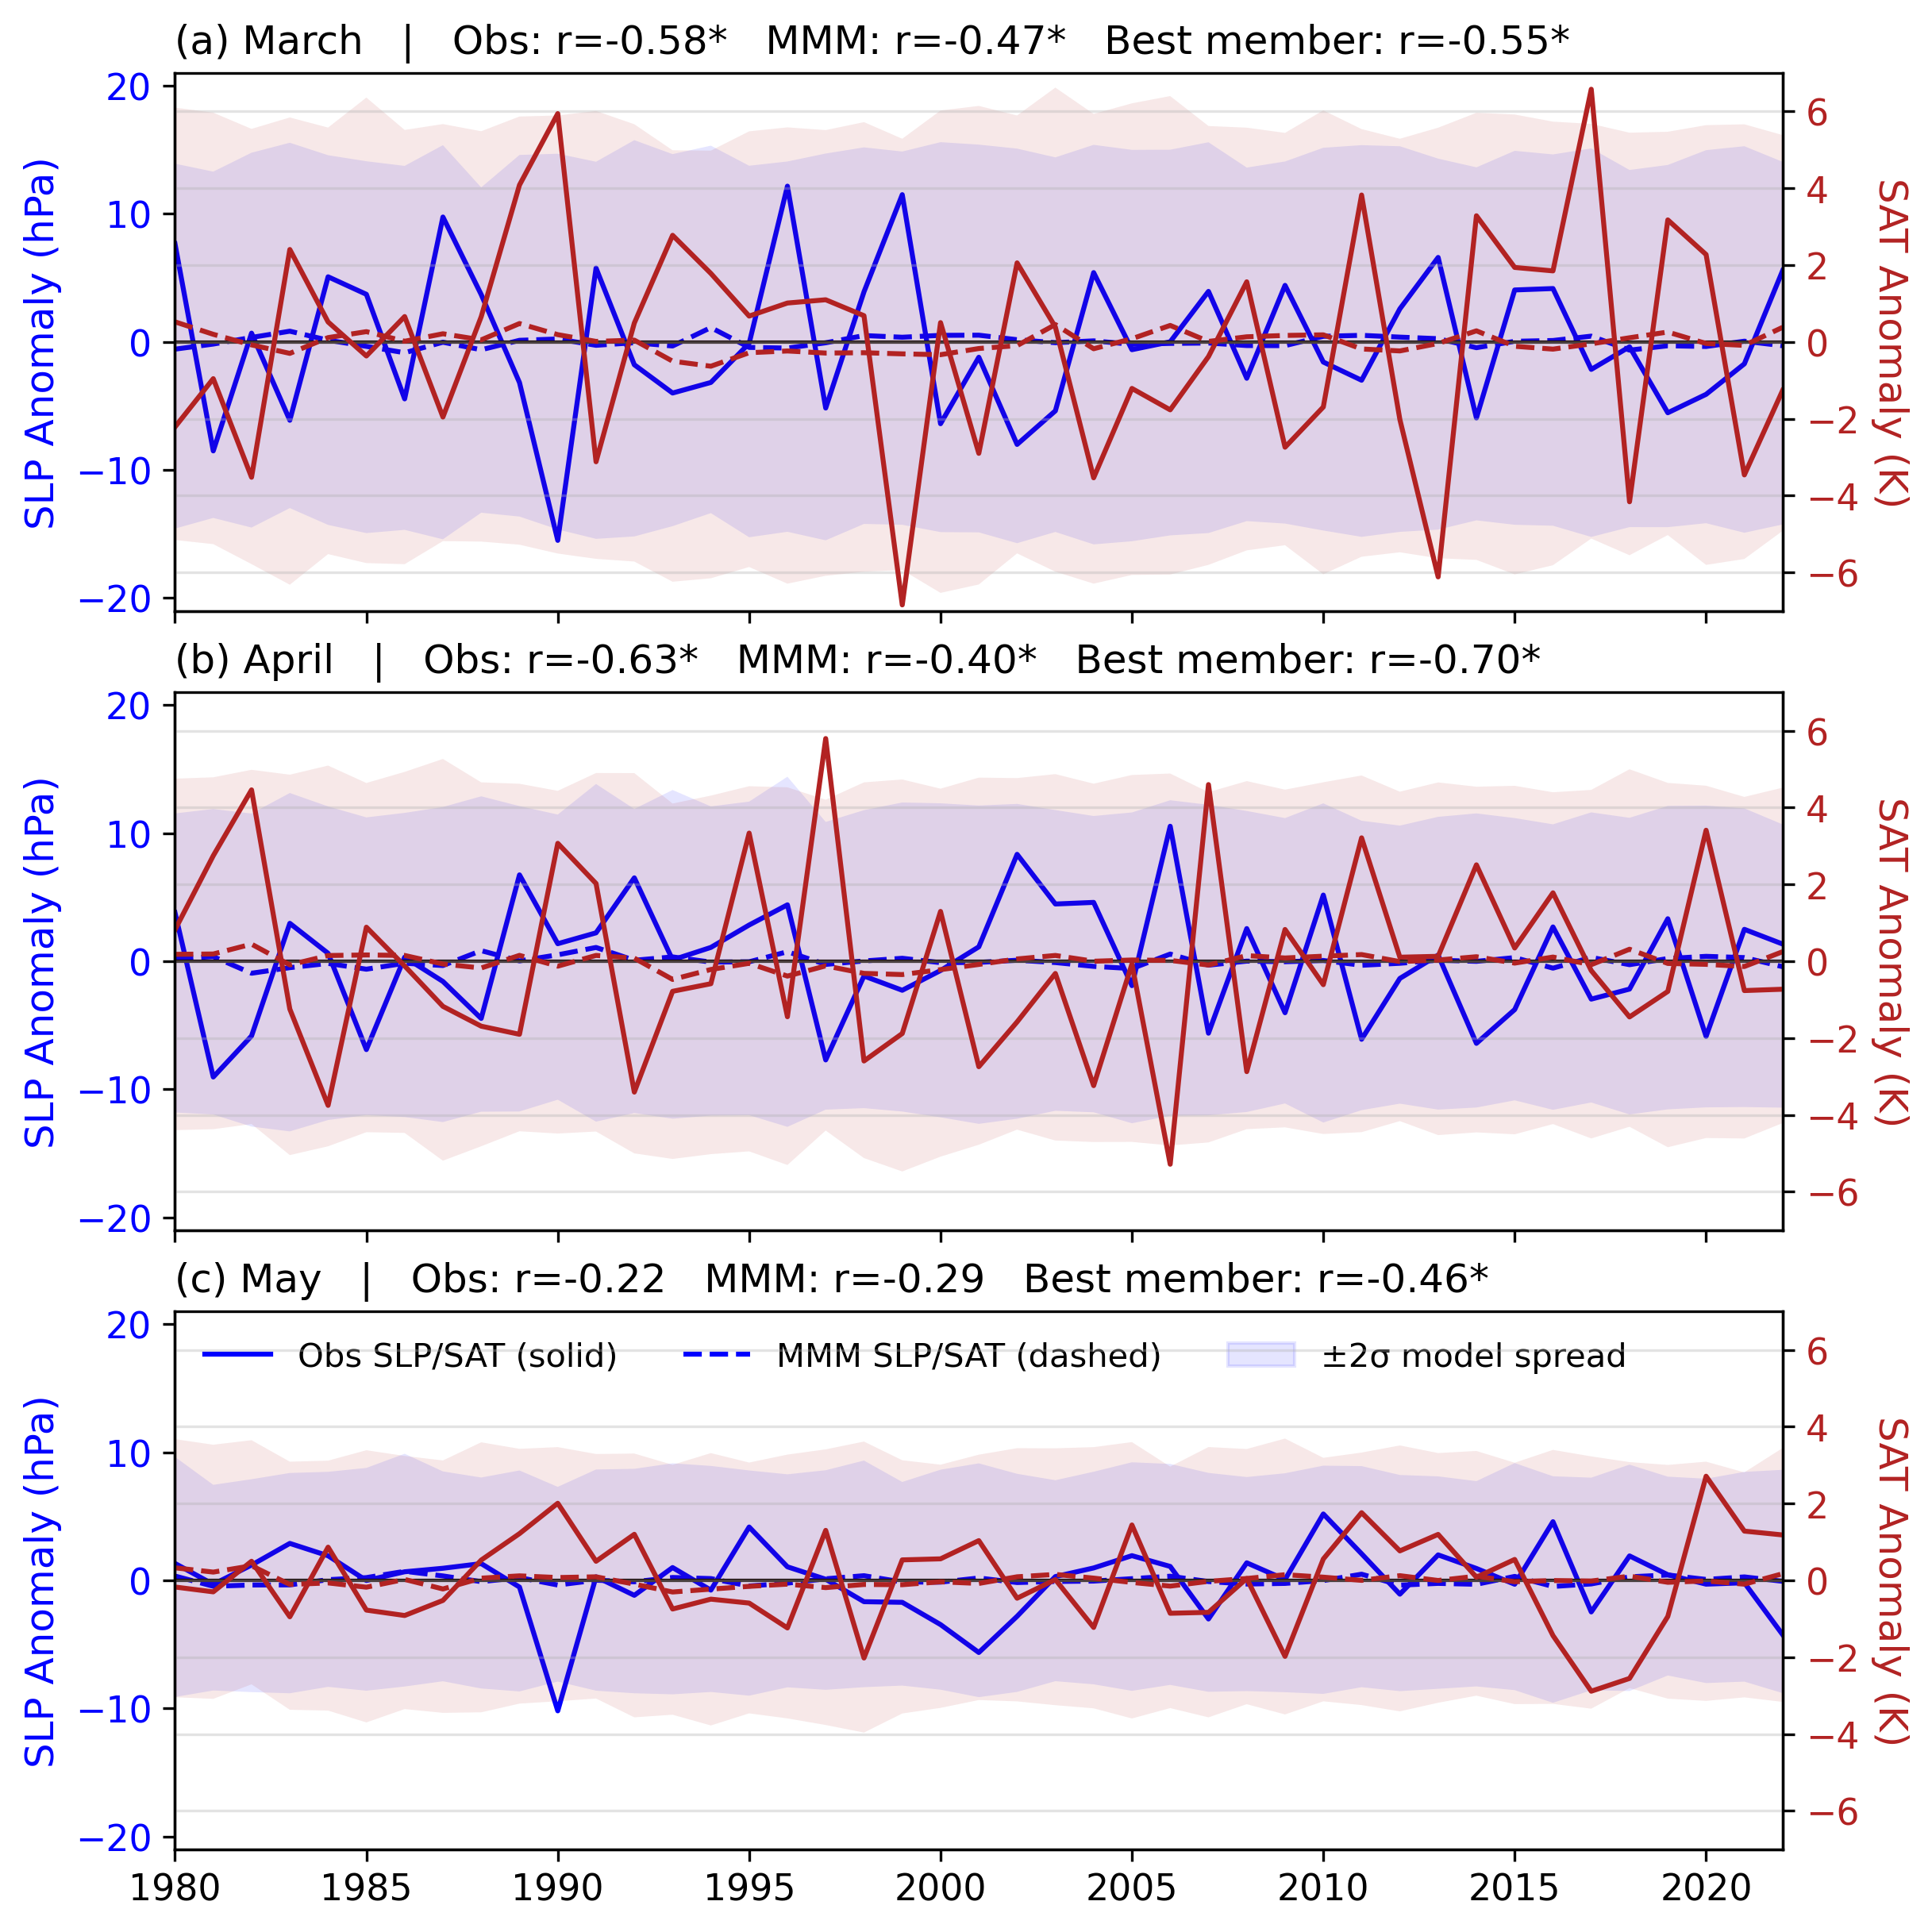

In [19]:
# ---- Plot ----
years = np.arange(1980, 2023)
slp_color = 'blue'
sat_color = 'firebrick'
mmm_color = 'steelblue'
ens_color = 'lightgrey'

fig, axes = plt.subplots(3, 1, figsize=(8, 8), dpi=DPI, constrained_layout=True, sharex=True)

obs_r_by_month = {}   # kept for reuse in Figure 7.2

for col in range(3):

    ax1 = axes[col]
    ax2 = ax1.twinx()
    bm = best_member[col]

    r_obs,  p_obs  = pearsonr(slp_dt[:, col],           sat_dt[:, col])
    r_mmm,  p_mmm  = pearsonr(mslp_dt[:, col],          msat_dt[:, col])
    r_best, p_best = pearsonr(ens_slp_dt[bm, :, col],   ens_sat_dt[bm, :, col])
    obs_r_by_month[MONTHS[col]] = r_obs

    # ---- Model spread (±2 std across members) ----
    ax1.fill_between(years, 
                     ens_slp_mean[:, col] - 2 * ens_slp_std[:, col],
                     ens_slp_mean[:, col] + 2 * ens_slp_std[:, col],
                     color=slp_color, alpha=0.10, label='±2σ SLP (models)',
                     edgecolor='none',)
    ax2.fill_between(years,
                     ens_sat_mean[:, col] - 2 * ens_sat_std[:, col],
                     ens_sat_mean[:, col] + 2 * ens_sat_std[:, col],
                     color=sat_color, alpha=0.10, label='±2σ SAT (models)',
                     edgecolor='none',)

    # ---- MMM lines (dashed, same colours) ----
    ax1.plot(years, mslp_dt[:, col], color=slp_color, lw=1.5,
             linestyle='--', label='MMM SLP')
    ax2.plot(years, msat_dt[:, col], color=sat_color, lw=1.5,
             linestyle='--', label='MMM SAT')

    # ---- Obs lines (solid) ----
    ax1.plot(years, slp_dt[:, col], color=slp_color, lw=1.5, label='Obs SLP')
    ax2.plot(years, sat_dt[:, col], color=sat_color, lw=1.5, label='Obs SAT')

    # ---- Correlations ----
    r_obs,  p_obs  = pearsonr(slp_dt[:, col],           sat_dt[:, col])
    r_mmm,  p_mmm  = pearsonr(mslp_dt[:, col],          msat_dt[:, col])
    r_best, p_best = pearsonr(ens_slp_dt[bm, :, col],   ens_sat_dt[bm, :, col])

    def pstr(r, p):
        sig = '*' if p < 0.05 else ''
        return f'r={r:.2f}{sig}'

    title = (f"({PANEL_LABELS[col]}) {MONTHS[col]}   |   "
             f"Obs: {pstr(r_obs, p_obs)}   "
             f"MMM: {pstr(r_mmm, p_mmm)}   "
             f"Best member: {pstr(r_best, p_best)}")
    ax1.set_title(title, fontsize=FS_TICK, loc='left')

    # ---- Formatting ----
    ax1.axhline(0, color='k', lw=1.0)
    ax1.set_xlim(1980, 2022)
    ax1.set_ylabel('SLP Anomaly (hPa)', color=slp_color, fontsize=12)
    ax1.tick_params(axis='y', labelcolor=slp_color)
    ax2.set_ylabel('SAT Anomaly (K)', color=sat_color, fontsize=12,
                   rotation=270, labelpad=15)
    ax2.tick_params(axis='y', labelcolor=sat_color)
    ax1.spines['top'].set_visible(False)
    ax2.grid(alpha=0.35)

    ax1.set_yticks([-20, -10, 0, 10, 20])
    ax1.set_ylim(-21, 21)
    ax2.set_ylim(-7, 7)
    ax1.tick_params(axis='both', which='major', labelsize=11)
    ax2.tick_params(axis='both', which='major', labelsize=11)

    # ---- Legend ----
    if col == 2:
        lines = [
            plt.Line2D([0], [0], color=slp_color, lw=1.5,           label='Obs SLP/SAT (solid)'),
            plt.Line2D([0], [0], color=slp_color, lw=1.5, ls='--',  label='MMM SLP/SAT (dashed)'),
            plt.matplotlib.patches.Patch(color=slp_color, alpha=0.1, edgecolor=None, label='±2σ model spread'),
        ]
        ax1.legend(handles=lines, ncols=3, frameon=False, fontsize=10, loc='upper left')

# plt.savefig('./figures/Figure7.png', dpi=DPI, bbox_inches='tight')
plt.show()

---
## Figure 7.2 — Internal-variability null distribution of the SLP-SAT correlation

Advisor note: "For each pair of internal time series from model, you can derive a correlation coefficient. For each month, you can plot the pdf of the correlation coefficient using the 9866 pairs along with those from observations (i.e., -0.58, -0.63 and -0.22) as vertical lines."

**Implementation note:** `sat_internal`/`slp_internal` hold 8966 samples per month (not 9866 -- using the actual loaded array length). A single Pearson r computed across all 8966 paired samples at once is one number, not a distribution, so I've read this as: bootstrap-resample sets of pairs matching the observational record length (43 years, as in Figure 7) from the 8966-sample pool, compute r for each resampled set, and use those draws to build the PDF. The observed r values are pulled directly from Figure 7 (`obs_r_by_month`) rather than hardcoded, so they'll match exactly rather than the two-decimal rounding in the advisor's note.

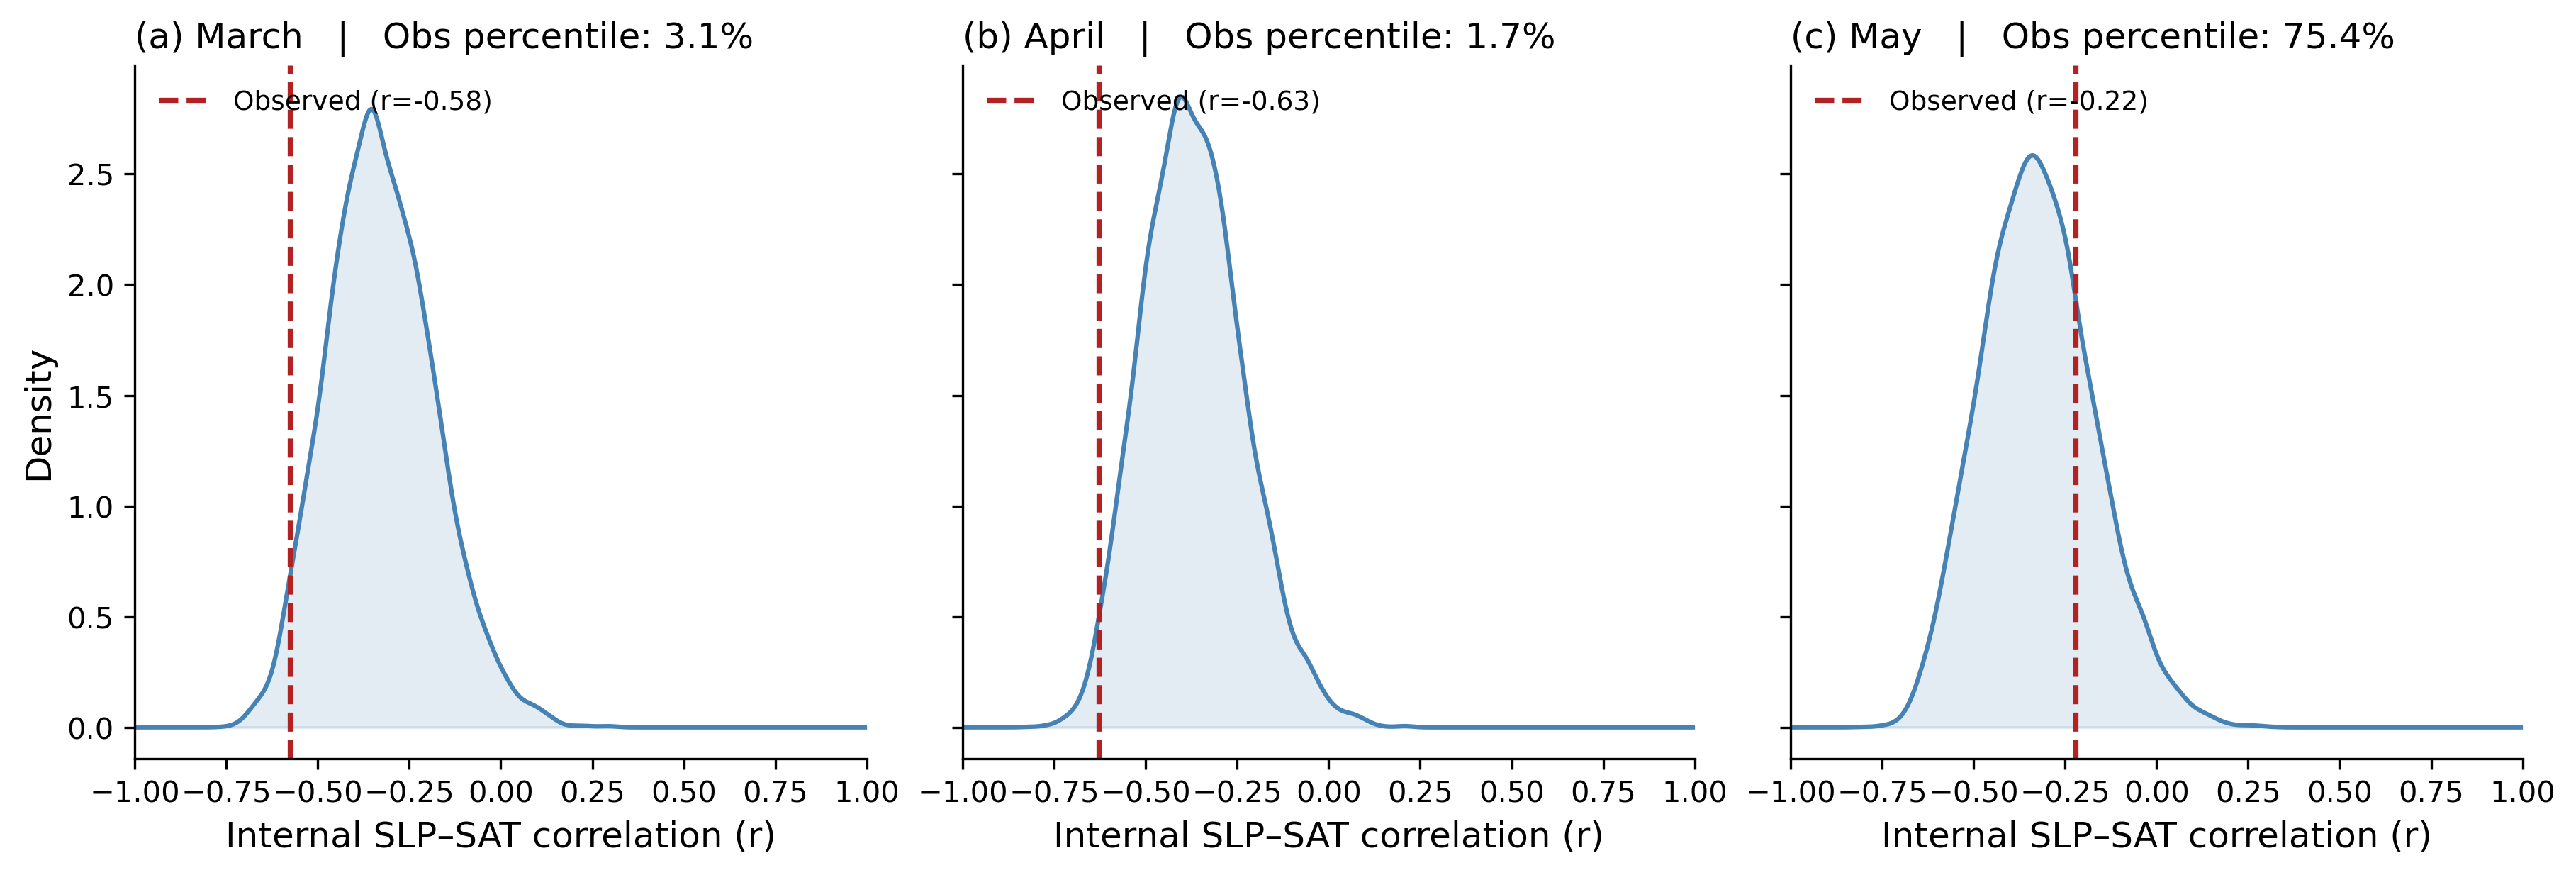

In [27]:
# ---- Figure 7.2: internal-variability null distribution of SLP-SAT r ----
N_BOOT = 10000
SAMPLE_SIZE = len(years)  # match the observational record length (Figure 7)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), dpi=DPI, constrained_layout=True, sharey=True)

for m, mon in enumerate(MONTHS):
    ax = axes[m]
    r_boot = bootstrap_correlation_pdf(x_avgs[m], y_avgs[m], sample_size=SAMPLE_SIZE, n_boot=N_BOOT, seed=42)

    kde = gaussian_kde(r_boot)
    xs = np.linspace(-1, 1, 400)
    ax.plot(xs, kde(xs), color='steelblue', lw=1.5)
    ax.fill_between(xs, kde(xs), color='steelblue', alpha=0.15)

    r_obs = obs_r_by_month[mon]
    ax.axvline(r_obs, color='firebrick', lw=1.75, linestyle='--',
               label=f'Observed (r={r_obs:.2f})')

    pct = 100 * np.mean(r_boot <= r_obs)
    ax.set_title(f"({PANEL_LABELS[m]}) {mon}   |   Obs percentile: {pct:.1f}%",
                 fontsize=FS_TICK, loc='left')
    ax.set_xlabel('Internal SLP–SAT correlation (r)', fontsize=FS_TICK)
    ax.set_xlim(-1, 1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='upper left', frameon=False, fontsize=9)
    if m == 0:
        ax.set_ylabel('Density', fontsize=FS_TICK)

# plt.savefig('./figures/Figure7_2.png', dpi=DPI, bbox_inches='tight')
plt.show()

---
## Table 1 — AA uncertainty (5th–95th percentile)

AA is a ratio of two trends, so need percentiles.

In [ ]:
# Per-model-mean AA for percentile computation
from glob import glob as _g3
_sim_paths2 = _g3('./data/sim-trends/*')
a_all, g_all = [], []
for path in _sim_paths2:
    ds = xr.open_dataset(path).X_SAT_SLP.isel(period=-6).sel(month=slice(2, 4))
    sat = np.nanmean(ds[:, :, :, :, 0].values * (0.213 / 0.260), axis=0)  # ens mean
    a_all.append(spatial_average(sat[:, lat >= 70], lat[lat >= 70], np.sum(lat >= 70)))
    g_all.append(spatial_average(sat, lat, len(lon)))
a_all = np.array(a_all)  # (n_models, 3)
g_all = np.array(g_all)
aa_all = a_all / g_all

print("Table 1 — Forced AA uncertainty (5th–95th percentile)")
print("-" * 60)
for i, mon in enumerate(MONTHS):
    a_mn = np.mean(a_all[:, i])
    a_p5 = np.percentile(a_all[:, i], 5)
    a_p95 = np.percentile(a_all[:, i], 95)

    g_mn = np.mean(g_all[:, i])
    g_p5 = np.percentile(g_all[:, i], 5)
    g_p95 = np.percentile(g_all[:, i], 95)

    aa_mn = np.mean(aa_all[:, i])
    aa_p5 = np.percentile(aa_all[:, i], 5)
    aa_p95 = np.percentile(aa_all[:, i], 95)

    print(f"  {mon}: Arctic = {a_mn:.3f} [{a_p5:.3f}, {a_p95:.3f}] | Global = {g_mn:.3f} [{g_p5:.3f}, {g_p95:.3f}] | AA = {aa_mn:.1f} [{aa_p5:.1f}, {aa_p95:.1f}] (5th–95th pct)")